# **DATA EXTRACTION**

### **INSTALLING REQUIRED LIBRARIES**

In [ ]:
!pip install yfinance
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git

  Using cached yfinance-0.2.52-py2.py3-none-any.whl.metadata (5.8 kB)
  Using cached multitasking-0.0.11-py3-none-any.whl.metadata (5.5 kB)
  Using cached lxml-5.3.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached frozendict-2.4.6-py311-none-any.whl.metadata (23 kB)
  Using cached peewee-3.17.8.tar.gz (948 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.2/112.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 63.5 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.8-cp311-cp311-linux_x86_64.whl size=886568 sha256=f5d1cafc5bee60b8b0deb17005141cd2d697001edf7756fb34df03f2e2629f23
  Stored in directory: /root/.cache/pip/wheels/ff/6c/15/506e25bc390de450a7fa53c155cd9b0fbd13ad3e84a9abc183
Successfully built pee

### **INSTALLING FINRL LIBRARIES**

In [ ]:
!pip install finrl
!pip install gymnasium
!pip install stable_baselines3
!pip install tabulate
!pip install alpaca-trade-api
!pip install exchange-calendars
!pip install stockstats
!pip install wrds

import yfinance as yf
import pandas as pd
from tabulate import tabulate
import time
import alpaca_trade_api as tradeapi



import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import torch

import numpy as np
from sklearn.preprocessing import MaxAbsScaler

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
#from finrl.meta.preprocessor.preprocessors import GroupByScaler
#from finrl.meta.env_portfolio_optimization.env_portfolio_optimization import PortfolioOptimizationEnv
#from finrl.agents.portfolio_optimization.models import DRLAgent
#from finrl.agents.portfolio_optimization.architectures import EIIE

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [ ]:
#!pip install PyPortfolioOpt
#!pip install scikit-learn
#!pip install stable-baselines3
#!pip install gymnasium
#!pip install pypfopt
#!pip install tqdm
#!pip install torch
#!pip install torchvision
#!pip install tensorboard

In [ ]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from sklearn.preprocessing import StandardScaler
import torch
from datetime import datetime
from tqdm import tqdm
import os
import json
import time


## **DATA SCRAPING**

**LIST OF TICKERS FROM CANADIAN STOCK MARKET**

In [ ]:
FIRST_SET_TICKERS = [
    "AAB.TO", "AAUC.TO", "AAV.TO", "ABX.TO", "AC.TO", "ACAA.TO", "ACB.TO", "ACD.TO", "ACQ.TO", "ACX.TO", "ADCO.TO", "ADEN.TO", "ADIV.TO", "ADN.TO", "AEG.TO", "AEM.TO", "AFN.TO", "AG.TO", "AGG.TO", "AGI.TO", "AI.TO", "AIDX.TO", "AIF.TO", "AIGO.TO", "AII.TO", "AIM.TO", "ALA.TO", "ALC.TO", "ALS.TO", "ALYA.TO", "AMAX.TO", "AMC.TO", "AMHE.TO", "AMM.TO", "AMZH.TO", "AND.TO", "ANRG.TO", "AOI.TO", "AOT.TO", "APLI.TO", "APM.TO", "APS.TO", "AQN.TO", "ARA.TO", "ARB.TO", "ARE.TO", "ARG.TO", "ARIS.TO", "ARTI.TO", "ARX.TO", "ASCU.TO", "ASM.TO", "ASND.TO", "ASTL.TO", "ATCU.TO", "ATD.TO", "ATH.TO", "ATRL.TO", "ATS.TO", "ATSX.TO", "ATZ.TO", "AUMN.TO", "AVCN.TO", "AVL.TO", "AVNT.TO", "AW.TO", "AYA.TO", "BABY.TO", "BAM.TO", "BANK.TO", "BASE.TO", "BB.TO", "BBUC.TO", "BCE.TO", "BCHT.TO", "BCT.TO", "BDGI.TO", "BDI.TO", "BDIV.TO", "BDT.TO", "BEPC.TO", "BEPR.TO", "BESG.TO", "BFIN.TO", "BGC.TO", "BGU.TO", "BHC.TO", "BIPC.TO", "BIR.TO", "BITF.TO", "BITI.TO", "BK.TO", "BKCC.TO", "BKCL.TO", "BKI.TO", "BLCO.TO", "BLDP.TO", "BLN.TO", "BLOV.TO", "BLX.TO", "BMAX.TO", "BMO.TO", "BN.TO", "BNC.TO", "BND.TO", "BNE.TO", "BNG.TO", "BNK.TO", "BNKL.TO", "BNS.TO", "BNT.TO", "BOND.TO", "BOS.TO", "BPRF.TO", "BR.TO", "BRAG.TO", "BRE.TO", "BREA.TO", "BRMI.TO", "BRY.TO", "BSKT.TO", "BSX.TO", "BTCC.TO", "BTCQ.TO", "BTCY.TO", "BTE.TO", "BTO.TO", "BU.TO", "BUI.TO", "BXF.TO", "BYD.TO", "BYL.TO", "CACB.TO", "CAE.TO", "CAFR.TO", "CAGG.TO", "CAGS.TO", "CALL.TO", "CANL.TO", "CAPG.TO", "CAPI.TO", "CAPM.TO", "CAPW.TO", "CARB.TO", "CARS.TO", "CAS.TO", "CASH.TO", "CBAL.TO", "CBCX.TO", "CBGR.TO", "CBH.TO", "CBIL.TO", "CBIN.TO", "CBL.TO", "CBND.TO", "CBNK.TO", "CBO.TO", "CBUG.TO", "CCA.TO", "CCBI.TO", "CCEI.TO", "CCM.TO", "CCNS.TO", "CCNV.TO", "CCO.TO", "CCOM.TO", "CCRE.TO", "CDEF.TO", "CDIV.TO", "CDLB.TO", "CDNA.TO", "CDR.TO", "CDZ.TO", "CEF.TO", "CEMI.TO", "CEMX.TO", "CEQT.TO", "CEU.TO", "CEW.TO", "CF.TO", "CFF.TO", "CFLX.TO", "CFP.TO", "CFRT.TO", "CFW.TO", "CFX.TO", "CG.TO", "CGAA.TO", "CGBI.TO", "CGDV.TO", "CGG.TO", "CGHY.TO", "CGI.TO", "CGIN.TO", "CGL.TO", "CGLO.TO", "CGO.TO", "CGR.TO", "CGRA.TO", "CGRE.TO", "CGRN.TO", "CGRO.TO", "CGX.TO", "CGXF.TO", "CGY.TO", "CHPS.TO", "CHR.TO", "CIA.TO", "CIAI.TO", "CIBR.TO", "CIC.TO", "CIEH.TO", "CIEI.TO", "CIEM.TO", "CIF.TO", "CIGI.TO", "CINF.TO", "CINT.TO", "CINV.TO", "CIX.TO", "CJ.TO", "CJT.TO", "CKI.TO", "CLF.TO", "CLG.TO", "CLML.TO", "CLS.TO", "CM.TO", "CMAG.TO", "CMAR.TO", "CMDO.TO", "CMG.TO", "CMGG.TO", "CMNY.TO", "CMOM.TO", "CMR.TO", "CMVX.TO", "CNCC.TO", "CNCL.TO", "CNDX.TO", "CNE.TO", "CNL.TO", "CNQ.TO", "CNR.TO", "CNT.TO", "CNV.TO", "COG.TO", "COMM.TO", "COPP.TO", "COPR.TO", "CORE.TO", "COW.TO", "CP.TO", "CPD.TO", "CPH.TO", "CPLS.TO", "CPX.TO", "CRDL.TO", "CRED.TO", "CRON.TO", "CROP.TO", "CRP.TO", "CRRX.TO", "CRWN.TO", "CS.TO", "CSAV.TO", "CSBI.TO", "CSCI.TO", "CSU.TO", "CTC.TO", "CTS.TO", "CTX.TO", "CU.TO", "CUBD.TO", "CUD.TO", "CUDV.TO", "CUEH.TO", "CUEI.TO", "CURA.TO", "CUTL.TO", "CVD.TO", "CVE.TO", "CVG.TO", "CVLU.TO", "CVO.TO", "CWB.TO", "CWEB.TO", "CWL.TO", "CWW.TO", "CXB.TO", "CXF.TO", "CXI.TO", "CYB.TO", "CYBR.TO", "CYH.TO", "DAMG.TO", "DANC.TO", "DATA.TO", "DAY.TO", "DBM.TO", "DBO.TO", "DCBC.TO", "DCBO.TO", "DCC.TO", "DCG.TO", "DCM.TO", "DCP.TO", "DCS.TO", "DCU.TO", "DF.TO", "DFN.TO", "DFY.TO", "DGR.TO", "DGRC.TO", "DGS.TO", "DIAM.TO", "DISC.TO", "DIV.TO", "DIVS.TO", "DLCG.TO", "DLR.TO", "DMEC.TO", "DMEI.TO", "DMEU.TO", "DML.TO", "DND.TO", "DNG.TO", "DNTL.TO", "DOL.TO", "DOO.TO", "DPM.TO", "DR.TO", "DRCU.TO", "DRFC.TO", "DRFD.TO", "DRFE.TO", "DRFG.TO", "DRFU.TO", "DRM.TO", "DRMC.TO", "DRMD.TO", "DRME.TO", "DRMU.TO", "DRT.TO", "DRX.TO", "DS.TO", "DSAE.TO", "DSG.TO", "DSV.TO", "DTOL.TO", "DXAU.TO", "DXB.TO", "DXBB.TO", "DXBC.TO", "DXBG.TO", "DXBU.TO", "DXC.TO", "DXCB.TO", "DXCO.TO", "DXCP.TO", "DXDB.TO", "DXEM.TO", "DXET.TO", "DXF.TO", "DXG.TO", "DXGE.TO", "DXIF.TO", "DXMO.TO", "DXN.TO", "DXO.TO", "DXP.TO", "DXQ.TO", "DXR.TO", "DXT.TO", "DXU.TO", "DXUS.TO", "DXV.TO", "DXW.TO", "DXZ.TO", "DYA.TO", "E.TO", "EAGR.TO", "EARN.TO", "EBIT.TO", "EBNK.TO", "ECN.TO", "ECO.TO", "ECOR.TO", "EDGE.TO", "EDGF.TO", "EDR.TO", "EDT.TO", "EDV.TO", "EFN.TO", "EFR.TO", "EFX.TO", "EGLX.TO", "EIF.TO", "ELD.TO", "ELEF.TO", "ELF.TO", "ELO.TO", "ELR.TO", "ELVA.TO", "EMA.TO", "EMAX.TO", "ENB.TO", "ENCC.TO", "ENCL.TO", "ENGH.TO", "ENS.TO", "EPRX.TO", "EQB.TO", "EQCC.TO", "EQCL.TO", "EQL.TO", "EQLI.TO", "EQX.TO", "ERD.TO", "ERO.TO", "ESG.TO", "ESGA.TO", "ESGB.TO", "ESGC.TO", "ESGE.TO", "ESGF.TO", "ESGG.TO", "ESGH.TO", "ESGY.TO", "ESI.TO", "ESM.TO", "ESP.TO", "ESPX.TO", "ET.TO", "ETC.TO", "ETG.TO", "ETHH.TO", "ETHI.TO", "ETHQ.TO", "ETHR.TO", "ETHY.TO", "ETP.TO", "ETSX.TO", "EVO.TO", "EVT.TO", "EXE.TO", "EXN.TO", "EXRO.TO", "FAP.TO", "FAR.TO", "FBGO.TO", "FBT.TO", "FBTC.TO", "FC.TO", "FCCD.TO", "FCCQ.TO", "FCCV.TO", "FCEM.TO", "FCGI.TO", "FCID.TO", "FCII.TO", "FCIQ.TO", "FCIV.TO", "FCMI.TO", "FCQH.TO", "FCRR.TO", "FCUD.TO", "FCUH.TO", "FCUQ.TO", "FCUV.TO", "FCVH.TO", "FDL.TO", "FDN.TO", "FDY.TO", "FEC.TO", "FETH.TO", "FF.TO", "FFH.TO", "FFM.TO", "FFN.TO", "FGB.TO", "FGEB.TO", "FGEP.TO", "FGGE.TO", "FGO.TO", "FGOV.TO", "FGRW.TO", "FHG.TO", "FHH.TO", "FHI.TO", "FHIS.TO", "FHQ.TO", "FIE.TO", "FIG.TO", "FIL.TO", "FINC.TO", "FINE.TO", "FINO.TO", "FLCI.TO", "FLCP.TO", "FLGA.TO", "FLI.TO", "FLNT.TO", "FLOW.TO", "FLSD.TO", "FLUS.TO", "FLX.TO", "FM.TO", "FMAX.TO", "FN.TO", "FNV.TO", "FOM.TO", "FOOD.TO", "FORA.TO", "FOUR.TO", "FPR.TO", "FRU.TO", "FRX.TO", "FSB.TO", "FSF.TO", "FSL.TO", "FST.TO", "FSV.TO", "FSY.TO", "FSZ.TO", "FT.TO", "FTG.TO", "FTHI.TO", "FTN.TO", "FTS.TO", "FTT.TO", "FTU.TO", "FURY.TO", "FVI.TO", "FVL.TO", "FXM.TO", "G.TO", "GATO.TO", "GAU.TO", "GBAL.TO", "GBT.TO", "GCBD.TO", "GCFE.TO", "GCG.TO", "GCL.TO", "GCNS.TO", "GCSC.TO", "GCTB.TO", "GCU.TO", "GDC.TO", "GDEP.TO", "GDI.TO", "GDL.TO", "GDPY.TO", "GDV.TO", "GEC.TO", "GEI.TO", "GENM.TO", "GEO.TO", "GEQT.TO", "GFL.TO", "GFP.TO", "GFR.TO", "GGD.TO", "GGRO.TO", "GH.TO", "GIGC.TO", "GIL.TO", "GIQG.TO", "GIQU.TO", "GLCC.TO", "GLDX.TO", "GLO.TO", "GLXY.TO", "GMIN.TO", "GMTN.TO", "GMX.TO", "GOLD.TO", "GOOS.TO", "GPMD.TO", "GRA.TO", "GRC.TO", "GRCC.TO", "GRGD.TO", "GRID.TO", "GRN.TO", "GRNI.TO", "GRO.TO", "GSY.TO", "GTE.TO", "GTWO.TO", "GUD.TO", "GURU.TO", "GVC.TO", "GWO.TO", "GXE.TO", "H.TO", "HAB.TO", "HAC.TO", "HAD.TO", "HAF.TO", "HAI.TO", "HAL.TO", "HAZ.TO", "HBA.TO", "HBAL.TO", "HBB.TO", "HBD.TO", "HBF.TO", "HBGD.TO", "HBIE.TO", "HBIG.TO", "HBIL.TO", "HBKD.TO", "HBKU.TO", "HBLK.TO", "HBM.TO", "HBND.TO", "HBNK.TO", "HBP.TO", "HBU.TO", "HBUG.TO", "HCA.TO", "HCAL.TO", "HCLN.TO", "HCON.TO", "HCRE.TO", "HDGE.TO", "HDIF.TO", "HDIV.TO", "HEB.TO", "HED.TO", "HEQL.TO", "HEQT.TO", "HERO.TO", "HEU.TO", "HEWB.TO", "HFD.TO", "HFG.TO", "HFIN.TO", "HFR.TO", "HFU.TO", "HGD.TO", "HGGG.TO", "HGR.TO", "HGRW.TO", "HGU.TO", "HGY.TO", "HHL.TO", "HHLE.TO", "HIG.TO", "HIND.TO", "HIU.TO", "HIX.TO", "HLF.TO", "HLIF.TO", "HLIT.TO", "HLPR.TO", "HLS.TO", "HMAX.TO", "HMMJ.TO", "HMP.TO", "HND.TO", "HNU.TO", "HOD.TO", "HOU.TO", "HPF.TO", "HPR.TO", "HPYM.TO", "HPYT.TO", "HQD.TO", "HQU.TO", "HRAA.TO", "HRED.TO", "HREU.TO", "HRIF.TO", "HRX.TO", "HSAV.TO", "HSD.TO", "HSH.TO", "HSU.TO", "HTA.TO","HTAE.TO", "HTB.TO", "HUBL.TO", "HUC.TO", "HUG.TO", "HULC.TO", "HUM.TO", "HUN.TO", "HURA.TO", "HUT.TO", "HUTE.TO", "HUTL.TO", "HUTS.TO", "HUV.TO", "HUZ.TO", "HWO.TO", "HWX.TO", "HXCN.TO", "HXD.TO", "HXDM.TO", "HXE.TO", "HXEM.TO", "HXF.TO", "HXH.TO", "HXQ.TO", "HXS.TO", "HXT.TO", "HXU.TO", "HXX.TO", "HYBR.TO", "HYLD.TO", "HZD.TO", "HZU.TO", "IAG.TO", "IAU.TO", "ICAE.TO", "ICE.TO", "ICPB.TO", "ICTE.TO", "IE.TO", "IFA.TO", "IFC.TO", "IFP.TO", "IFRF.TO", "IGAF.TO", "IGB.TO", "IGEO.TO", "IGET.TO", "IGM.TO", "IIAE.TO", "IICE.TO", "III.TO", "IIMF.TO", "IITE.TO", "ILGB.TO", "ILLM.TO", "IMG.TO", "IMO.TO", "IMP.TO", "INAI.TO", "INCM.TO", "INE.TO", "INOC.TO", "IPCO.TO", "IPO.TO", "IQD.TO", "IS.TO", "ISC.TO", "ISCB.TO", "ISO.TO", "ISTE.TO", "ITH.TO", "IUAE.TO", "IUCE.TO", "IUMF.TO", "IUTE.TO", "IVN.TO", "IVQ.TO", "IWBE.TO", "IXTE.TO", "JAG.TO", "JAPN.TO", "JEPI.TO", "JEPQ.TO", "JOY.TO", "JWEL.TO", "K.TO", "KBL.TO", "KEC.TO", "KEI.TO", "KEL.TO", "KEY.TO", "KILO.TO", "KITS.TO", "KLS.TO", "KNGC.TO", "KNGU.TO", "KNGX.TO", "KNT.TO", "KPT.TO", "KRN.TO", "KSI.TO", "KXS.TO", "L.TO", "LAAC.TO", "LABS.TO", "LAC.TO", "LAM.TO", "LB.TO", "LBS.TO", "LCFS.TO", "LCS.TO", "LEAD.TO", "LFE.TO", "LGD.TO", "LGO.TO", "LIF.TO", "LIFE.TO", "LIRC.TO", "LLHE.TO", "LLYH.TO", "LMAX.TO", "LN.TO", "LNF.TO", "LNR.TO", "LPAY.TO", "LSPD.TO", "LSPK.TO", "LUC.TO", "LUG.TO", "LUN.TO", "LYCT.TO", "LYFR.TO", "MAG.TO", "MAL.TO", "MARI.TO", "MART.TO", "MATR.TO", "MBAL.TO", "MBX.TO", "MCAD.TO", "MCB.TO", "MCLC.TO", "MCLV.TO", "MCON.TO", "MCSB.TO", "MCSM.TO", "MDA.TO", "MDI.TO", "MDIV.TO", "MDNA.TO", "MDP.TO", "MDVD.TO", "MEG.TO", "MEQ.TO", "MEQT.TO", "MFC.TO", "MFI.TO", "MFT.TO", "MG.TO", "MGA.TO", "MGAB.TO", "MGB.TO", "MGDV.TO", "MGQE.TO", "MGRW.TO", "MHCD.TO", "MINF.TO", "MINN.TO", "MINT.TO", "MIQE.TO", "MIVG.TO", "MKB.TO", "MKP.TO", "MND.TO", "MNO.TO", "MNS.TO", "MNT.TO", "MNXT.TO", "MNY.TO", "MOGO.TO", "MORE.TO", "MPAY.TO", "MPC.TO", "MPVD.TO", "MPY.TO", "MRC.TO", "MRD.TO", "MRE.TO", "MREL.TO", "MRU.TO", "MSA.TO", "MSCL.TO", "MSFH.TO", "MSHE.TO", "MSV.TO", "MTAV.TO", "MTL.TO", "MTY.TO", "MUB.TO", "MULC.TO", "MULV.TO", "MUMC.TO", "MUSA.TO", "MUX.TO", "MWLV.TO", "MX.TO", "MXG.TO", "NA.TO", "NALT.TO", "NANO.TO", "NCF.TO", "NDIV.TO", "NDM.TO", "NEO.TO", "NEXT.TO", "NFI.TO", "NG.TO", "NGD.TO", "NGDN.TO", "NGEX.TO", "NGPE.TO", "NGT.TO", "NGUP.TO", "NHYB.TO", "NINT.TO", "NOA.TO", "NPI.TO", "NPK.TO", "NPRF.TO", "NPS.TO", "NREA.TO", "NRGY.TO", "NSCB.TO", "NSCC.TO", "NSCE.TO", "NSGE.TO", "NSSB.TO", "NTR.TO", "NUAG.TO", "NUBF.TO", "NUMI.TO", "NUSA.TO", "NVA.TO", "NVDH.TO", "NVHE.TO", "NVO.TO", "NWC.TO", "NXE.TO", "NXF.TO", "NXTG.TO", "OBE.TO", "OGC.TO", "OGD.TO", "OGI.TO", "OLA.TO", "OLY.TO", "ONC.TO", "ONEB.TO", "ONEC.TO", "ONEQ.TO", "ONEX.TO", "OPT.TO", "OR.TO", "ORA.TO", "ORE.TO", "ORV.TO", "OTEX.TO", "OVV.TO", "PAAS.TO", "PABF.TO", "PACF.TO", "PAGF.TO", "PAY.TO", "PAYF.TO", "PAYL.TO", "PAYM.TO", "PAYS.TO", "PBD.TO", "PBH.TO", "PBI.TO", "PBL.TO", "PCOR.TO", "PD.TO", "PDC.TO", "PDF.TO", "PDIV.TO", "PDN.TO", "PDV.TO", "PEA.TO", "PET.TO", "PEY.TO", "PFAA.TO", "PFAE.TO", "PFCB.TO", "PFIA.TO", "PFL.TO", "PFLS.TO", "PFMN.TO", "PFSS.TO", "PGIC.TO", "PHR.TO", "PHX.TO", "PHYS.TO", "PID.TO", "PIF.TO", "PIN.TO", "PINC.TO", "PKI.TO", "PLDI.TO", "PLV.TO", "PME.TO", "PMET.TO", "PMIF.TO", "PMM.TO", "PMNT.TO", "PNE.TO", "PNP.TO", "POU.TO", "POW.TO", "PPL.TO", "PPLN.TO", "PPR.TO", "PPTA.TO", "PR.TO", "PRA.TO", "PRB.TO", "PREF.TO", "PRL.TO", "PRM.TO", "PRN.TO", "PRQ.TO", "PRU.TO", "PRYM.TO", "PSA.TO", "PSB.TO", "PSD.TO", "PSI.TO", "PSK.TO", "PSLV.TO", "PTM.TO", "PWI.TO", "PXC.TO", "PXS.TO", "PXT.TO", "PYF.TO", "PYR.TO", "PZA.TO", "PZW.TO", "QAH.TO", "QASH.TO", "QBB.TO", "QBTC.TO", "QBTL.TO", "QCE.TO", "QCLN.TO", "QCN.TO", "QDX.TO", "QDXB.TO", "QDXH.TO", "QEBH.TO", "QEBL.TO", "QEC.TO", "QEE.TO", "QHY.TO", "QIE.TO", "QINF.TO", "QIPT.TO", "QLB.TO", "QMAX.TO", "QQC.TO", "QQCC.TO", "QQCE.TO", "QQCI.TO", "QQCL.TO", "QQEQ.TO", "QQJE.TO", "QQJR.TO", "QQQL.TO", "QQQT.TO", "QQQX.TO", "QQQY.TO", "QRC.TO", "QRET.TO", "QSB.TO", "QSR.TO", "QTLT.TO", "QTRH.TO", "QUB.TO", "QUIG.TO", "QUS.TO", "QUU.TO", "QXM.TO", "RAAA.TO", "RATE.TO", "RBA.TO", "RBNK.TO", "RBO.TO", "RBOT.TO", "RBY.TO", "RCD.TO", "RCDC.TO", "RCG.TO", "RCH.TO", "RDBH.TO", "REAL.TO", "RGQN.TO", "RGQO.TO", "RGQP.TO", "RGQQ.TO", "RGQR.TO", "RGQS.TO", "RID.TO", "RIDH.TO", "RIFI.TO", "RIIN.TO", "RING.TO", "RIRA.TO", "RIT.TO", "RLB.TO", "RMAX.TO", "ROOT.TO", "RPD.TO", "RPDH.TO", "RPF.TO", "RPSB.TO", "RQN.TO", "RQO.TO", "RQP.TO", "RQQ.TO", "RQR.TO", "RQS.TO", "RS.TO", "RSI.TO", "RTG.TO", "RUBH.TO", "RUBY.TO", "RUD.TO", "RUDB.TO", "RUDC.TO", "RUDH.TO", "RUP.TO", "RUQN.TO", "RUQO.TO", "RUQQ.TO", "RUQR.TO", "RUQS.TO", "RUS.TO", "RUSB.TO", "RVX.TO", "RXD.TO", "RY.TO", "S.TO", "SAFE.TO", "SAM.TO", "SAP.TO", "SAU.TO", "SBC.TO", "SBI.TO", "SBT.TO", "SCR.TO", "SCY.TO", "SDE.TO", "SEA.TO", "SEC.TO", "SES.TO", "SFC.TO", "SFD.TO", "SFI.TO", "SFTC.TO", "SGLD.TO", "SGY.TO", "SHLE.TO", "SHOP.TO", "SIA.TO", "SII.TO", "SIL.TO", "SIS.TO", "SJ.TO", "SKE.TO", "SKYY.TO", "SLF.TO", "SLR.TO", "SLS.TO", "SMAX.TO", "SMC.TO", "SMT.TO", "SOBO.TO", "SOIL.TO", "SOLG.TO", "SOY.TO", "SPAY.TO", "SPB.TO", "SPFD.TO", "SPLT.TO", "SPPP.TO", "SSL.TO", "SSRM.TO", "STC.TO", "STCK.TO", "STEP.TO", "STGO.TO", "STLR.TO", "STN.TO", "STPL.TO", "SU.TO", "SVA.TO", "SVB.TO", "SVI.TO", "SVM.TO", "SVR.TO", "SWP.TO", "SXI.TO", "SXP.TO", "SYLD.TO", "SYZ.TO", "T.TO", "TA.TO", "TAL.TO", "TBAL.TO", "TBCE.TO", "TBCF.TO", "TBCG.TO", "TBIL.TO", "TBL.TO", "TBNK.TO", "TC.TO", "TCBN.TO", "TCLB.TO", "TCLV.TO", "TCON.TO", "TCS.TO", "TCSB.TO", "TCSH.TO", "TCW.TO", "TD.TO", "TDB.TO", "TDOC.TO", "TEC.TO", "TECH.TO", "TECI.TO", "TECX.TO", "TERM.TO", "TF.TO", "TFII.TO", "TFPM.TO", "TGAF.TO", "TGED.TO", "TGFI.TO", "TGGR.TO", "TGO.TO", "TGRE.TO", "TGRO.TO", "TH.TO", "The.TO", "THNC.TO", "THU.TO", "TI.TO", "TIH.TO", "TILV.TO", "TINF.TO", "TIPS.TO", "TIXT.TO", "TKN.TO", "TKO.TO", "TLF.TO", "TLG.TO", "TLO.TO", "TLRY.TO", "TLV.TO", "TMQ.TO", "TNZ.TO", "TOT.TO", "TOU.TO", "TOWR.TO", "TOY.TO", "TPE.TO", "TPRF.TO", "TPU.TO", "TPZ.TO", "TQCD.TO", "TQGD.TO", "TQGM.TO", "TQSM.TO", "TRI.TO", "TRP.TO", "TRVI.TO", "TRVL.TO", "TRX.TO", "TRZ.TO", "TSAT.TO", "TSK.TO", "TSL.TO", "TSND.TO", "TSU.TO", "TTNM.TO", "TTP.TO", "TTTX.TO", "TUED.TO", "TUEX.TO", "TUHY.TO", "TULB.TO", "TULV.TO", "TUSB.TO", "TVE.TO", "TVK.TO", "TWC.TO", "TWM.TO", "TXF.TO", "TXG.TO", "TXP.TO", "UDA.TO", "UDIV.TO", "UMAX.TO", "UMI.TO", "UNC.TO", "UNI.TO", "URB.TO", "URC.TO", "URE.TO", "USA.TO", "USCC.TO", "USCL.TO", "USSL.TO", "USSX.TO", "UTES.TO", "UTIL.TO", "VA.TO", "VAB.TO", "VALT.TO", "VBAL.TO", "VBNK.TO", "VCB.TO", "VCE.TO", "VCIP.TO", "VCM.TO", "VCN.TO", "VCNS.TO", "VDU.TO", "VDY.TO", "VE.TO", "VEE.TO", "VEF.TO", "VEQT.TO", "VET.TO", "VFV.TO", "VGG.TO", "VGH.TO", "VGRO.TO", "VGV.TO", "VGZ.TO", "VHI.TO", "VI.TO", "VIDY.TO", "VIU.TO", "VLB.TO", "VLE.TO", "VLN.TO", "VMO.TO", "VNP.TO", "VOXR.TO", "VQS.TO", "VRE.TO", "VRIF.TO", "VRN.TO", "VRTS.TO", "VSB.TO", "VSC.TO", "VSP.TO", "VUN.TO", "VUS.TO", "VVL.TO", "VVO.TO", "VVSG.TO", "VXC.TO", "VXM.TO", "VZLA.TO", "WCN.TO", "WCP.TO", "WDO.TO", "WEED.TO", "WEF.TO", "WELL.TO", "WFC.TO", "WFG.TO", "WGX.TO", "WILD.TO", "WJX.TO", "WLLW.TO", "WM.TO", "WN.TO", "WNDR.TO", "WOMN.TO", "WPK.TO", "WPM.TO", "WPRT.TO", "WRG.TO", "WRN.TO", "WRX.TO", "WSP.TO", "WSRD.TO", "WSRI.TO", "WTE.TO", "WXM.TO", "X.TO", "XAD.TO", "XAGG.TO", "XAGH.TO", "XAM.TO", "XAU.TO", "XAW.TO", "XBAL.TO", "XBB.TO", "XBM.TO", "XCB.TO", "XCBG.TO", "XCBU.TO", "XCD.TO", "XCG.TO", "XCH.TO", "XCHP.TO", "XCLN.TO", "XCNS.TO", "XCS.TO", "XCSR.TO", "XCV.TO", "XDG.TO", "XDGH.TO", "XDIV.TO", "XDNA.TO", "XDRV.TO", "XDSR.TO", "XDU.TO", "XDUH.TO", "XDV.TO", "XEB.TO", "XEC.TO", "XEF.TO", "XEG.TO", "XEH.TO", "XEI.TO", "XEM.TO", "XEMC.TO", "XEN.TO", "XEQT.TO", "XESG.TO", "XETM.TO", "XEU.TO", "XEXP.TO", "XFH.TO", "XFLB.TO", "XFLI.TO", "XFLX.TO", "XFN.TO", "XFR.TO", "XGB.TO", "XGD.TO", "XGI.TO", "XGRO.TO", "XHAK.TO", "XHB.TO", "XHC.TO", "XHD.TO", "XHU.TO", "XHY.TO", "XIC.TO", "XID.TO", "XIG.TO", "XIGS.TO", "XIN.TO", "XINC.TO", "XIT.TO", "XIU.TO", "XLB.TO", "XLY.TO", "XMA.TO", "XMC.TO", "XMD.TO", "XMH.TO", "XMI.TO", "XML.TO", "XMM.TO", "XMS.TO", "XMTM.TO", "XMU.TO", "XMV.TO", "XMW.TO", "XMY.TO", "XPF.TO", "XQB.TO", "XQLT.TO", "XQQ.TO", "XQQU.TO", "XRB.TO", "XRE.TO", "XSAB.TO", "XSB.TO", "XSC.TO", "XSE.TO", "XSEA.TO", "XSEM.TO", "XSH.TO", "XSHG.TO", "XSHU.TO", "XSI.TO", "XSMC.TO", "XSMH.TO", "XSP.TO", "XSPC.TO", "XST.TO", "XSTB.TO", "XSTH.TO", "XSTP.TO", "XSU.TO", "XSUS.TO", "XTC.TO", "XTD.TO", "XTG.TO", "XTLH.TO", "XTLT.TO", "XTR.TO", "XTRA.TO", "XUH.TO", "XUS.TO", "XUSC.TO", "XUSF.TO", "XUSR.TO", "XUT.TO", "XUU.TO", "XVLU.TO", "XWD.TO", "Y.TO", "YCM.TO", "YGR.TO", "YRB.TO", "ZACE.TO", "ZAG.TO", "ZBAL.TO", "ZBBB.TO", "ZBI.TO", "ZBK.TO", "ZCB.TO", "ZCDB.TO", "ZCH.TO", "ZCLN.TO", "ZCM.TO", "ZCN.TO", "ZCON.TO", "ZCPB.TO", "ZCS.TO", "ZDB.TO", "ZDH.TO", "ZDI.TO", "ZDJ.TO", "ZDM.TO", "ZDV.TO", "ZDY.TO", "ZEA.TO", "ZEAT.TO", "ZEB.TO", "ZEF.TO", "ZEM.TO", "ZEO.TO", "ZEQ.TO", "ZEQT.TO", "ZESG.TO", "ZFC.TO", "ZFH.TO", "ZFL.TO", "ZFM.TO", "ZFN.TO", "ZFS.TO", "ZGB.TO", "ZGD.TO", "ZGI.TO", "ZGLD.TO", "ZGLH.TO", "ZGQ.TO", "ZGRN.TO", "ZGRO.TO", "ZGSB.TO", "ZHP.TO", "ZHU.TO", "ZHY.TO", "ZIC.TO", "ZID.TO", "ZIN.TO", "ZIQ.TO", "ZIU.TO", "ZJG.TO", "ZJK.TO", "ZJPN.TO", "ZLB.TO", "ZLC.TO", "ZLD.TO", "ZLE.TO", "ZLH.TO", "ZLI.TO", "ZLSC.TO", "ZLSU.TO", "ZLU.TO", "ZMBS.TO", "ZMI.TO", "ZMID.TO", "ZMMK.TO", "ZMP.TO", "ZMSB.TO", "ZMT.TO", "ZMU.TO", "ZNQ.TO", "ZPAY.TO", "ZPH.TO", "ZPL.TO", "ZPR.TO", "ZPS.TO", "ZPW.TO", "ZQB.TO", "ZQQ.TO", "ZRE.TO", "ZRR.TO", "ZSB.TO", "ZSDB.TO", "ZSML.TO", "ZSP.TO", "ZST.TO", "ZSU.TO", "ZTIP.TO", "ZUAG.TO", "ZUB.TO", "ZUCM.TO", "ZUD.TO", "ZUE.TO", "ZUGE.TO", "ZUH.TO", "ZUP.TO", "ZUQ.TO", "ZUT.TO", "ZVC.TO", "ZVU.TO", "ZWA.TO", "ZWB.TO", "ZWC.TO", "ZWE.TO", "ZWEN.TO", "ZWG.TO", "ZWH.TO", "ZWHC.TO", "ZWK.TO", "ZWP.TO", "ZWQT.TO", "ZWS.TO", "ZWT.TO", "ZWU.TO", "ZXM.TO", "ZZZD.TO"
]
print(len(FIRST_SET_TICKERS))

1637


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import yfinance as yf
import pandas as pd
import time

# Function to fetch historical data for a list of tickers
def fetch_all_historical_data(ticker_list, start_date, end_date, requests_per_minute=100):
    data = []
    delay = 60 / requests_per_minute  # Calculate delay to respect rate limits

    for i, ticker in enumerate(ticker_list):
        try:
            print(f"Fetching data for: {ticker}")
            # Download historical data for the ticker
            ticker_data = yf.download(ticker, start=start_date, end=end_date, progress=False)

            # Check if data is empty
            if ticker_data.empty:
                print(f"Warning: No data found for {ticker}")
                continue

            # Add a 'tic' column with the ticker symbol
            ticker_data['tic'] = ticker
            ticker_data.reset_index(inplace=True)  # Reset index to bring 'Date' as a column

            # Select only the required columns
            ticker_data = ticker_data[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'tic']]

            # Add day of the week
            ticker_data['day'] = pd.to_datetime(ticker_data['Date']).dt.dayofweek

            # Rename columns to lowercase
            ticker_data.columns = ['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day']

            # Append to the data list
            data.append(ticker_data)

        except Exception as e:
            print(f"Error fetching data for {ticker}: {e}")

        # Delay to respect the request limit
        if i < len(ticker_list) - 1:
            time.sleep(delay)

    # Combine all data into a single DataFrame
    if not data:
        print("Error: No data found for any of the specified tickers.")
        return pd.DataFrame()
    else:
        combined_data = pd.concat(data, ignore_index=True)

        # Sort by 'date' and 'tic'
        sorted_data = combined_data.sort_values(by=['date', 'tic'], ascending=[True, True])
        return sorted_data

# Example usage
ticker_list = FIRST_SET_TICKERS
start_date = "2004-01-01"
end_date = "2024-12-31"

# Fetch historical data
historical_data = fetch_all_historical_data(
    ticker_list=ticker_list,
    start_date=start_date,
    end_date=end_date,
    requests_per_minute=100
)

# Verify the shape and columns
print("DataFrame columns:", historical_data.columns.tolist())
print("DataFrame shape:", historical_data.shape)
print("\nFirst few rows:")
print(historical_data.head())


Fetching data for: AAB.TO
Fetching data for: AAUC.TO
Fetching data for: AAV.TO
Fetching data for: ABX.TO
Fetching data for: AC.TO
Fetching data for: ACAA.TO
Fetching data for: ACB.TO
Fetching data for: ACD.TO
Fetching data for: ACQ.TO
Fetching data for: ACX.TO
Fetching data for: ADCO.TO
Fetching data for: ADEN.TO
Fetching data for: ADIV.TO
Fetching data for: ADN.TO
Fetching data for: AEG.TO
Fetching data for: AEM.TO
Fetching data for: AFN.TO
Fetching data for: AG.TO
Fetching data for: AGG.TO
Fetching data for: AGI.TO
Fetching data for: AI.TO
Fetching data for: AIDX.TO
Fetching data for: AIF.TO
Fetching data for: AIGO.TO
Fetching data for: AII.TO
Fetching data for: AIM.TO
Fetching data for: ALA.TO
Fetching data for: ALC.TO
Fetching data for: ALS.TO
Fetching data for: ALYA.TO
Fetching data for: AMAX.TO
Fetching data for: AMC.TO
Fetching data for: AMHE.TO
Fetching data for: AMM.TO
Fetching data for: AMZH.TO
Fetching data for: AND.TO
Fetching data for: ANRG.TO
Fetching data for: AOI.TO
Fet

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['APM.TO']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (1d 2004-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1072933200, endDate = 1735621200")')


Fetching data for: APS.TO
Fetching data for: AQN.TO
Fetching data for: ARA.TO
Fetching data for: ARB.TO
Fetching data for: ARE.TO
Fetching data for: ARG.TO
Fetching data for: ARIS.TO
Fetching data for: ARTI.TO
Fetching data for: ARX.TO
Fetching data for: ASCU.TO
Fetching data for: ASM.TO
Fetching data for: ASND.TO
Fetching data for: ASTL.TO
Fetching data for: ATCU.TO
Fetching data for: ATD.TO
Fetching data for: ATH.TO
Fetching data for: ATRL.TO
Fetching data for: ATS.TO
Fetching data for: ATSX.TO
Fetching data for: ATZ.TO
Fetching data for: AUMN.TO
Fetching data for: AVCN.TO
Fetching data for: AVL.TO
Fetching data for: AVNT.TO
Fetching data for: AW.TO
Fetching data for: AYA.TO
Fetching data for: BABY.TO
Fetching data for: BAM.TO
Fetching data for: BANK.TO
Fetching data for: BASE.TO
Fetching data for: BB.TO
Fetching data for: BBUC.TO
Fetching data for: BCE.TO
Fetching data for: BCHT.TO
Fetching data for: BCT.TO
Fetching data for: BDGI.TO
Fetching data for: BDI.TO
Fetching data for: BDIV

ERROR:yfinance:Could not get exchangeTimezoneName for ticker 'CDZ.TO' reason: 'chart'
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CDZ.TO']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


Fetching data for: CEF.TO
Fetching data for: CEMI.TO
Fetching data for: CEMX.TO
Fetching data for: CEQT.TO
Fetching data for: CEU.TO
Fetching data for: CEW.TO
Fetching data for: CF.TO
Fetching data for: CFF.TO
Fetching data for: CFLX.TO
Fetching data for: CFP.TO
Fetching data for: CFRT.TO
Fetching data for: CFW.TO
Fetching data for: CFX.TO
Fetching data for: CG.TO
Fetching data for: CGAA.TO
Fetching data for: CGBI.TO
Fetching data for: CGDV.TO
Fetching data for: CGG.TO
Fetching data for: CGHY.TO
Fetching data for: CGI.TO
Fetching data for: CGIN.TO
Fetching data for: CGL.TO
Fetching data for: CGLO.TO
Fetching data for: CGO.TO
Fetching data for: CGR.TO
Fetching data for: CGRA.TO
Fetching data for: CGRE.TO
Fetching data for: CGRN.TO
Fetching data for: CGRO.TO
Fetching data for: CGX.TO
Fetching data for: CGXF.TO
Fetching data for: CGY.TO
Fetching data for: CHPS.TO
Fetching data for: CHR.TO
Fetching data for: CIA.TO
Fetching data for: CIAI.TO
Fetching data for: CIBR.TO
Fetching data for: CI

...

Fetching data for: XDIV.TO
Fetching data for: XDNA.TO
Fetching data for: XDRV.TO
Fetching data for: XDSR.TO
Fetching data for: XDU.TO


ERROR:yfinance:Could not get exchangeTimezoneName for ticker 'XDU.TO' reason: 'chart'
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['XDU.TO']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


Fetching data for: XDUH.TO
Fetching data for: XDV.TO
Fetching data for: XEB.TO
Fetching data for: XEC.TO
Fetching data for: XEF.TO
Fetching data for: XEG.TO
Fetching data for: XEH.TO
Fetching data for: XEI.TO
Fetching data for: XEM.TO
Fetching data for: XEMC.TO
Fetching data for: XEN.TO
Fetching data for: XEQT.TO
Fetching data for: XESG.TO
Fetching data for: XETM.TO
Fetching data for: XEU.TO
Fetching data for: XEXP.TO
Fetching data for: XFH.TO
Fetching data for: XFLB.TO
Fetching data for: XFLI.TO
Fetching data for: XFLX.TO
Fetching data for: XFN.TO
Fetching data for: XFR.TO
Fetching data for: XGB.TO
Fetching data for: XGD.TO
Fetching data for: XGI.TO
Fetching data for: XGRO.TO
Fetching data for: XHAK.TO
Fetching data for: XHB.TO
Fetching data for: XHC.TO
Fetching data for: XHD.TO
Fetching data for: XHU.TO
Fetching data for: XHY.TO
Fetching data for: XIC.TO
Fetching data for: XID.TO
Fetching data for: XIG.TO
Fetching data for: XIGS.TO
Fetching data for: XIN.TO
Fetching data for: XINC.TO

ERROR:yfinance:Could not get exchangeTimezoneName for ticker 'XTD.TO' reason: 'chart'
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['XTD.TO']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')


Fetching data for: XTG.TO
Fetching data for: XTLH.TO
Fetching data for: XTLT.TO
Fetching data for: XTR.TO
Fetching data for: XTRA.TO
Fetching data for: XUH.TO
Fetching data for: XUS.TO
Fetching data for: XUSC.TO
Fetching data for: XUSF.TO
Fetching data for: XUSR.TO
Fetching data for: XUT.TO
Fetching data for: XUU.TO
Fetching data for: XVLU.TO
Fetching data for: XWD.TO
Fetching data for: Y.TO
Fetching data for: YCM.TO
Fetching data for: YGR.TO
Fetching data for: YRB.TO
Fetching data for: ZACE.TO
Fetching data for: ZAG.TO
Fetching data for: ZBAL.TO
Fetching data for: ZBBB.TO
Fetching data for: ZBI.TO
Fetching data for: ZBK.TO
Fetching data for: ZCB.TO
Fetching data for: ZCDB.TO
Fetching data for: ZCH.TO
Fetching data for: ZCLN.TO
Fetching data for: ZCM.TO
Fetching data for: ZCN.TO
Fetching data for: ZCON.TO
Fetching data for: ZCPB.TO
Fetching data for: ZCS.TO
Fetching data for: ZDB.TO
Fetching data for: ZDH.TO
Fetching data for: ZDI.TO
Fetching data for: ZDJ.TO
Fetching data for: ZDM.TO


In [ ]:
historical_data

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,date,close,high,low,open,volume,tic,day
952970,2004-01-01,0.105000,0.105000,0.105000,0.105000,0,DYA.TO,3
985564,2004-01-01,1.378000,1.378000,1.378000,1.378000,0,EDT.TO,3
3143022,2004-01-01,0.300000,0.300000,0.300000,0.300000,0,TSK.TO,3
0,2004-01-02,0.489625,0.489625,0.489625,0.489625,0,AAB.TO,4
9404,2004-01-02,22.070263,22.211644,21.817266,21.899118,413000,ABX.TO,4
...,...,...,...,...,...,...,...,...
4058709,2024-12-30,20.230000,20.309999,20.150000,20.309999,700,ZWS.TO,0
4059695,2024-12-30,53.099998,53.360001,52.830002,53.299999,11600,ZWT.TO,0
4062941,2024-12-30,10.510000,10.520000,10.430000,10.500000,168700,ZWU.TO,0
4065476,2024-12-30,42.599998,42.610001,42.599998,42.610001,300,ZXM.TO,0


In [ ]:
# Define the list of stock tickers
tickers = ["AAB.TO", "AAUC.TO", "AAV.TO", "ABX.TO", "AC.TO", "ACAA.TO", "ACB.TO", "ACD.TO", "ACQ.TO", "ACX.TO", "ADCO.TO", "ADEN.TO", "ADIV.TO", "ADN.TO", "AEG.TO", "AEM.TO", "AFN.TO", "AG.TO", "AGG.TO", "AGI.TO", "AI.TO", "AIDX.TO", "AIF.TO", "AIGO.TO", "AII.TO", "AIM.TO", "ALA.TO", "ALC.TO", "ALS.TO", "ALYA.TO", "AMAX.TO", "AMC.TO", "AMHE.TO", "AMM.TO", "AMZH.TO", "AND.TO", "ANRG.TO", "AOI.TO", "AOT.TO", "APLI.TO", "APM.TO", "APS.TO", "AQN.TO", "ARA.TO", "ARB.TO", "ARE.TO", "ARG.TO", "ARIS.TO", "ARTI.TO", "ARX.TO", "ASCU.TO", "ASM.TO", "ASND.TO", "ASTL.TO", "ATCU.TO", "ATD.TO", "ATH.TO", "ATRL.TO", "ATS.TO", "ATSX.TO", "ATZ.TO", "AUMN.TO", "AVCN.TO", "AVL.TO", "AVNT.TO", "AW.TO", "AYA.TO", "BABY.TO", "BAM.TO", "BANK.TO", "BASE.TO", "BB.TO", "BBUC.TO", "BCE.TO", "BCHT.TO", "BCT.TO", "BDGI.TO", "BDI.TO", "BDIV.TO", "BDT.TO", "BEPC.TO", "BEPR.TO", "BESG.TO", "BFIN.TO", "BGC.TO", "BGU.TO", "BHC.TO", "BIPC.TO", "BIR.TO", "BITF.TO", "BITI.TO", "BK.TO", "BKCC.TO", "BKCL.TO", "BKI.TO", "BLCO.TO", "BLDP.TO", "BLN.TO", "BLOV.TO", "BLX.TO", "BMAX.TO", "BMO.TO", "BN.TO", "BNC.TO", "BND.TO", "BNE.TO", "BNG.TO", "BNK.TO", "BNKL.TO", "BNS.TO", "BNT.TO", "BOND.TO", "BOS.TO", "BPRF.TO", "BR.TO", "BRAG.TO", "BRE.TO", "BREA.TO", "BRMI.TO", "BRY.TO", "BSKT.TO", "BSX.TO", "BTCC.TO", "BTCQ.TO", "BTCY.TO", "BTE.TO", "BTO.TO", "BU.TO", "BUI.TO", "BXF.TO", "BYD.TO", "BYL.TO", "CACB.TO", "CAE.TO", "CAFR.TO", "CAGG.TO", "CAGS.TO", "CALL.TO", "CANL.TO", "CAPG.TO", "CAPI.TO", "CAPM.TO", "CAPW.TO", "CARB.TO", "CARS.TO", "CAS.TO", "CASH.TO", "CBAL.TO", "CBCX.TO", "CBGR.TO", "CBH.TO", "CBIL.TO", "CBIN.TO", "CBL.TO", "CBND.TO", "CBNK.TO", "CBO.TO", "CBUG.TO", "CCA.TO", "CCBI.TO", "CCEI.TO", "CCM.TO", "CCNS.TO", "CCNV.TO", "CCO.TO", "CCOM.TO", "CCRE.TO", "CDEF.TO", "CDIV.TO", "CDLB.TO", "CDNA.TO", "CDR.TO", "CDZ.TO", "CEF.TO", "CEMI.TO", "CEMX.TO", "CEQT.TO", "CEU.TO", "CEW.TO", "CF.TO", "CFF.TO", "CFLX.TO", "CFP.TO", "CFRT.TO", "CFW.TO", "CFX.TO", "CG.TO", "CGAA.TO", "CGBI.TO", "CGDV.TO", "CGG.TO", "CGHY.TO", "CGI.TO", "CGIN.TO", "CGL.TO", "CGLO.TO", "CGO.TO", "CGR.TO", "CGRA.TO", "CGRE.TO", "CGRN.TO", "CGRO.TO", "CGX.TO", "CGXF.TO", "CGY.TO", "CHPS.TO", "CHR.TO", "CIA.TO", "CIAI.TO", "CIBR.TO", "CIC.TO", "CIEH.TO", "CIEI.TO", "CIEM.TO", "CIF.TO", "CIGI.TO", "CINF.TO", "CINT.TO", "CINV.TO", "CIX.TO", "CJ.TO", "CJT.TO", "CKI.TO", "CLF.TO", "CLG.TO", "CLML.TO", "CLS.TO", "CM.TO", "CMAG.TO", "CMAR.TO", "CMDO.TO", "CMG.TO", "CMGG.TO", "CMNY.TO", "CMOM.TO", "CMR.TO", "CMVX.TO", "CNCC.TO", "CNCL.TO", "CNDX.TO", "CNE.TO", "CNL.TO", "CNQ.TO", "CNR.TO", "CNT.TO", "CNV.TO", "COG.TO", "COMM.TO", "COPP.TO", "COPR.TO", "CORE.TO", "COW.TO", "CP.TO", "CPD.TO", "CPH.TO", "CPLS.TO", "CPX.TO", "CRDL.TO", "CRED.TO", "CRON.TO", "CROP.TO", "CRP.TO", "CRRX.TO", "CRWN.TO", "CS.TO", "CSAV.TO", "CSBI.TO", "CSCI.TO", "CSU.TO", "CTC.TO", "CTS.TO", "CTX.TO", "CU.TO", "CUBD.TO", "CUD.TO", "CUDV.TO", "CUEH.TO", "CUEI.TO", "CURA.TO", "CUTL.TO", "CVD.TO", "CVE.TO", "CVG.TO", "CVLU.TO", "CVO.TO", "CWB.TO", "CWEB.TO", "CWL.TO", "CWW.TO", "CXB.TO", "CXF.TO", "CXI.TO", "CYB.TO", "CYBR.TO", "CYH.TO", "DAMG.TO", "DANC.TO", "DATA.TO", "DAY.TO", "DBM.TO", "DBO.TO", "DCBC.TO", "DCBO.TO", "DCC.TO", "DCG.TO", "DCM.TO", "DCP.TO", "DCS.TO", "DCU.TO", "DF.TO", "DFN.TO", "DFY.TO", "DGR.TO", "DGRC.TO", "DGS.TO", "DIAM.TO", "DISC.TO", "DIV.TO", "DIVS.TO", "DLCG.TO", "DLR.TO", "DMEC.TO", "DMEI.TO", "DMEU.TO", "DML.TO", "DND.TO", "DNG.TO", "DNTL.TO", "DOL.TO", "DOO.TO", "DPM.TO", "DR.TO", "DRCU.TO", "DRFC.TO", "DRFD.TO", "DRFE.TO", "DRFG.TO", "DRFU.TO", "DRM.TO", "DRMC.TO", "DRMD.TO", "DRME.TO", "DRMU.TO", "DRT.TO", "DRX.TO", "DS.TO", "DSAE.TO", "DSG.TO", "DSV.TO", "DTOL.TO", "DXAU.TO", "DXB.TO", "DXBB.TO", "DXBC.TO", "DXBG.TO", "DXBU.TO", "DXC.TO", "DXCB.TO", "DXCO.TO", "DXCP.TO", "DXDB.TO", "DXEM.TO", "DXET.TO", "DXF.TO", "DXG.TO", "DXGE.TO", "DXIF.TO", "DXMO.TO", "DXN.TO", "DXO.TO", "DXP.TO", "DXQ.TO", "DXR.TO", "DXT.TO", "DXU.TO", "DXUS.TO", "DXV.TO", "DXW.TO", "DXZ.TO", "DYA.TO", "E.TO", "EAGR.TO", "EARN.TO", "EBIT.TO", "EBNK.TO", "ECN.TO", "ECO.TO", "ECOR.TO", "EDGE.TO", "EDGF.TO", "EDR.TO", "EDT.TO", "EDV.TO", "EFN.TO", "EFR.TO", "EFX.TO", "EGLX.TO", "EIF.TO", "ELD.TO", "ELEF.TO", "ELF.TO", "ELO.TO", "ELR.TO", "ELVA.TO", "EMA.TO", "EMAX.TO", "ENB.TO", "ENCC.TO", "ENCL.TO", "ENGH.TO", "ENS.TO", "EPRX.TO", "EQB.TO", "EQCC.TO", "EQCL.TO", "EQL.TO", "EQLI.TO", "EQX.TO", "ERD.TO", "ERO.TO", "ESG.TO", "ESGA.TO", "ESGB.TO", "ESGC.TO", "ESGE.TO", "ESGF.TO", "ESGG.TO", "ESGH.TO", "ESGY.TO", "ESI.TO", "ESM.TO", "ESP.TO", "ESPX.TO", "ET.TO", "ETC.TO", "ETG.TO", "ETHH.TO", "ETHI.TO", "ETHQ.TO", "ETHR.TO", "ETHY.TO", "ETP.TO", "ETSX.TO", "EVO.TO", "EVT.TO", "EXE.TO", "EXN.TO", "EXRO.TO", "FAP.TO", "FAR.TO", "FBGO.TO", "FBT.TO", "FBTC.TO", "FC.TO", "FCCD.TO", "FCCQ.TO", "FCCV.TO", "FCEM.TO", "FCGI.TO", "FCID.TO", "FCII.TO", "FCIQ.TO", "FCIV.TO", "FCMI.TO", "FCQH.TO", "FCRR.TO", "FCUD.TO", "FCUH.TO", "FCUQ.TO", "FCUV.TO", "FCVH.TO", "FDL.TO", "FDN.TO", "FDY.TO", "FEC.TO", "FETH.TO", "FF.TO", "FFH.TO", "FFM.TO", "FFN.TO", "FGB.TO", "FGEB.TO", "FGEP.TO", "FGGE.TO", "FGO.TO", "FGOV.TO", "FGRW.TO", "FHG.TO", "FHH.TO", "FHI.TO", "FHIS.TO", "FHQ.TO", "FIE.TO", "FIG.TO", "FIL.TO", "FINC.TO", "FINE.TO", "FINO.TO", "FLCI.TO", "FLCP.TO", "FLGA.TO", "FLI.TO", "FLNT.TO", "FLOW.TO", "FLSD.TO", "FLUS.TO", "FLX.TO", "FM.TO", "FMAX.TO", "FN.TO", "FNV.TO", "FOM.TO", "FOOD.TO", "FORA.TO", "FOUR.TO", "FPR.TO", "FRU.TO", "FRX.TO", "FSB.TO", "FSF.TO", "FSL.TO", "FST.TO", "FSV.TO", "FSY.TO", "FSZ.TO", "FT.TO", "FTG.TO", "FTHI.TO", "FTN.TO", "FTS.TO", "FTT.TO", "FTU.TO", "FURY.TO", "FVI.TO", "FVL.TO", "FXM.TO", "G.TO", "GATO.TO", "GAU.TO", "GBAL.TO", "GBT.TO", "GCBD.TO", "GCFE.TO", "GCG.TO", "GCL.TO", "GCNS.TO", "GCSC.TO", "GCTB.TO", "GCU.TO", "GDC.TO", "GDEP.TO", "GDI.TO", "GDL.TO", "GDPY.TO", "GDV.TO", "GEC.TO", "GEI.TO", "GENM.TO", "GEO.TO", "GEQT.TO", "GFL.TO", "GFP.TO", "GFR.TO", "GGD.TO", "GGRO.TO", "GH.TO", "GIGC.TO", "GIL.TO", "GIQG.TO", "GIQU.TO", "GLCC.TO", "GLDX.TO", "GLO.TO", "GLXY.TO", "GMIN.TO", "GMTN.TO", "GMX.TO", "GOLD.TO", "GOOS.TO", "GPMD.TO", "GRA.TO", "GRC.TO", "GRCC.TO", "GRGD.TO", "GRID.TO", "GRN.TO", "GRNI.TO", "GRO.TO", "GSY.TO", "GTE.TO", "GTWO.TO", "GUD.TO", "GURU.TO", "GVC.TO", "GWO.TO", "GXE.TO", "H.TO", "HAB.TO", "HAC.TO", "HAD.TO", "HAF.TO", "HAI.TO", "HAL.TO", "HAZ.TO", "HBA.TO", "HBAL.TO", "HBB.TO", "HBD.TO", "HBF.TO", "HBGD.TO", "HBIE.TO", "HBIG.TO", "HBIL.TO", "HBKD.TO", "HBKU.TO", "HBLK.TO", "HBM.TO", "HBND.TO", "HBNK.TO", "HBP.TO", "HBU.TO", "HBUG.TO", "HCA.TO", "HCAL.TO", "HCLN.TO", "HCON.TO", "HCRE.TO", "HDGE.TO", "HDIF.TO", "HDIV.TO", "HEB.TO", "HED.TO", "HEQL.TO", "HEQT.TO", "HERO.TO", "HEU.TO", "HEWB.TO", "HFD.TO", "HFG.TO", "HFIN.TO", "HFR.TO", "HFU.TO", "HGD.TO", "HGGG.TO", "HGR.TO", "HGRW.TO", "HGU.TO", "HGY.TO", "HHL.TO", "HHLE.TO", "HIG.TO", "HIND.TO", "HIU.TO", "HIX.TO", "HLF.TO", "HLIF.TO", "HLIT.TO", "HLPR.TO", "HLS.TO", "HMAX.TO", "HMMJ.TO", "HMP.TO", "HND.TO", "HNU.TO", "HOD.TO", "HOU.TO", "HPF.TO", "HPR.TO", "HPYM.TO", "HPYT.TO", "HQD.TO", "HQU.TO", "HRAA.TO", "HRED.TO", "HREU.TO", "HRIF.TO", "HRX.TO", "HSAV.TO", "HSD.TO", "HSH.TO", "HSU.TO", "HTA.TO","HTAE.TO", "HTB.TO", "HUBL.TO", "HUC.TO", "HUG.TO", "HULC.TO", "HUM.TO", "HUN.TO", "HURA.TO", "HUT.TO", "HUTE.TO", "HUTL.TO", "HUTS.TO", "HUV.TO", "HUZ.TO", "HWO.TO", "HWX.TO", "HXCN.TO", "HXD.TO", "HXDM.TO", "HXE.TO", "HXEM.TO", "HXF.TO", "HXH.TO", "HXQ.TO", "HXS.TO", "HXT.TO", "HXU.TO", "HXX.TO", "HYBR.TO", "HYLD.TO", "HZD.TO", "HZU.TO", "IAG.TO", "IAU.TO", "ICAE.TO", "ICE.TO", "ICPB.TO", "ICTE.TO", "IE.TO", "IFA.TO", "IFC.TO", "IFP.TO", "IFRF.TO", "IGAF.TO", "IGB.TO", "IGEO.TO", "IGET.TO", "IGM.TO", "IIAE.TO", "IICE.TO", "III.TO", "IIMF.TO", "IITE.TO", "ILGB.TO", "ILLM.TO", "IMG.TO", "IMO.TO", "IMP.TO", "INAI.TO", "INCM.TO", "INE.TO", "INOC.TO", "IPCO.TO", "IPO.TO", "IQD.TO", "IS.TO", "ISC.TO", "ISCB.TO", "ISO.TO", "ISTE.TO", "ITH.TO", "IUAE.TO", "IUCE.TO", "IUMF.TO", "IUTE.TO", "IVN.TO", "IVQ.TO", "IWBE.TO", "IXTE.TO", "JAG.TO", "JAPN.TO", "JEPI.TO", "JEPQ.TO", "JOY.TO", "JWEL.TO", "K.TO", "KBL.TO", "KEC.TO", "KEI.TO", "KEL.TO", "KEY.TO", "KILO.TO", "KITS.TO", "KLS.TO", "KNGC.TO", "KNGU.TO", "KNGX.TO", "KNT.TO", "KPT.TO", "KRN.TO", "KSI.TO", "KXS.TO", "L.TO", "LAAC.TO", "LABS.TO", "LAC.TO", "LAM.TO", "LB.TO", "LBS.TO", "LCFS.TO", "LCS.TO", "LEAD.TO", "LFE.TO", "LGD.TO", "LGO.TO", "LIF.TO", "LIFE.TO", "LIRC.TO", "LLHE.TO", "LLYH.TO", "LMAX.TO", "LN.TO", "LNF.TO", "LNR.TO", "LPAY.TO", "LSPD.TO", "LSPK.TO", "LUC.TO", "LUG.TO", "LUN.TO", "LYCT.TO", "LYFR.TO", "MAG.TO", "MAL.TO", "MARI.TO", "MART.TO", "MATR.TO", "MBAL.TO", "MBX.TO", "MCAD.TO", "MCB.TO", "MCLC.TO", "MCLV.TO", "MCON.TO", "MCSB.TO", "MCSM.TO", "MDA.TO", "MDI.TO", "MDIV.TO", "MDNA.TO", "MDP.TO", "MDVD.TO", "MEG.TO", "MEQ.TO", "MEQT.TO", "MFC.TO", "MFI.TO", "MFT.TO", "MG.TO", "MGA.TO", "MGAB.TO", "MGB.TO", "MGDV.TO", "MGQE.TO", "MGRW.TO", "MHCD.TO", "MINF.TO", "MINN.TO", "MINT.TO", "MIQE.TO", "MIVG.TO", "MKB.TO", "MKP.TO", "MND.TO", "MNO.TO", "MNS.TO", "MNT.TO", "MNXT.TO", "MNY.TO", "MOGO.TO", "MORE.TO", "MPAY.TO", "MPC.TO", "MPVD.TO", "MPY.TO", "MRC.TO", "MRD.TO", "MRE.TO", "MREL.TO", "MRU.TO", "MSA.TO", "MSCL.TO", "MSFH.TO", "MSHE.TO", "MSV.TO", "MTAV.TO", "MTL.TO", "MTY.TO", "MUB.TO", "MULC.TO", "MULV.TO", "MUMC.TO", "MUSA.TO", "MUX.TO", "MWLV.TO", "MX.TO", "MXG.TO", "NA.TO", "NALT.TO", "NANO.TO", "NCF.TO", "NDIV.TO", "NDM.TO", "NEO.TO", "NEXT.TO", "NFI.TO", "NG.TO", "NGD.TO", "NGDN.TO", "NGEX.TO", "NGPE.TO", "NGT.TO", "NGUP.TO", "NHYB.TO", "NINT.TO", "NOA.TO", "NPI.TO", "NPK.TO", "NPRF.TO", "NPS.TO", "NREA.TO", "NRGY.TO", "NSCB.TO", "NSCC.TO", "NSCE.TO", "NSGE.TO", "NSSB.TO", "NTR.TO", "NUAG.TO", "NUBF.TO", "NUMI.TO", "NUSA.TO", "NVA.TO", "NVDH.TO", "NVHE.TO", "NVO.TO", "NWC.TO", "NXE.TO", "NXF.TO", "NXTG.TO", "OBE.TO", "OGC.TO", "OGD.TO", "OGI.TO", "OLA.TO", "OLY.TO", "ONC.TO", "ONEB.TO", "ONEC.TO", "ONEQ.TO", "ONEX.TO", "OPT.TO", "OR.TO", "ORA.TO", "ORE.TO", "ORV.TO", "OTEX.TO", "OVV.TO", "PAAS.TO", "PABF.TO", "PACF.TO", "PAGF.TO", "PAY.TO", "PAYF.TO", "PAYL.TO", "PAYM.TO", "PAYS.TO", "PBD.TO", "PBH.TO", "PBI.TO", "PBL.TO", "PCOR.TO", "PD.TO", "PDC.TO", "PDF.TO", "PDIV.TO", "PDN.TO", "PDV.TO", "PEA.TO", "PET.TO", "PEY.TO", "PFAA.TO", "PFAE.TO", "PFCB.TO", "PFIA.TO", "PFL.TO", "PFLS.TO", "PFMN.TO", "PFSS.TO", "PGIC.TO", "PHR.TO", "PHX.TO", "PHYS.TO", "PID.TO", "PIF.TO", "PIN.TO", "PINC.TO", "PKI.TO", "PLDI.TO", "PLV.TO", "PME.TO", "PMET.TO", "PMIF.TO", "PMM.TO", "PMNT.TO", "PNE.TO", "PNP.TO", "POU.TO", "POW.TO", "PPL.TO", "PPLN.TO", "PPR.TO", "PPTA.TO", "PR.TO", "PRA.TO", "PRB.TO", "PREF.TO", "PRL.TO", "PRM.TO", "PRN.TO", "PRQ.TO", "PRU.TO", "PRYM.TO", "PSA.TO", "PSB.TO", "PSD.TO", "PSI.TO", "PSK.TO", "PSLV.TO", "PTM.TO", "PWI.TO", "PXC.TO", "PXS.TO", "PXT.TO", "PYF.TO", "PYR.TO", "PZA.TO", "PZW.TO", "QAH.TO", "QASH.TO", "QBB.TO", "QBTC.TO", "QBTL.TO", "QCE.TO", "QCLN.TO", "QCN.TO", "QDX.TO", "QDXB.TO", "QDXH.TO", "QEBH.TO", "QEBL.TO", "QEC.TO", "QEE.TO", "QHY.TO", "QIE.TO", "QINF.TO", "QIPT.TO", "QLB.TO", "QMAX.TO", "QQC.TO", "QQCC.TO", "QQCE.TO", "QQCI.TO", "QQCL.TO", "QQEQ.TO", "QQJE.TO", "QQJR.TO", "QQQL.TO", "QQQT.TO", "QQQX.TO", "QQQY.TO", "QRC.TO", "QRET.TO", "QSB.TO", "QSR.TO", "QTLT.TO", "QTRH.TO", "QUB.TO", "QUIG.TO", "QUS.TO", "QUU.TO", "QXM.TO", "RAAA.TO", "RATE.TO", "RBA.TO", "RBNK.TO", "RBO.TO", "RBOT.TO", "RBY.TO", "RCD.TO", "RCDC.TO", "RCG.TO", "RCH.TO", "RDBH.TO", "REAL.TO", "RGQN.TO", "RGQO.TO", "RGQP.TO", "RGQQ.TO", "RGQR.TO", "RGQS.TO", "RID.TO", "RIDH.TO", "RIFI.TO", "RIIN.TO", "RING.TO", "RIRA.TO", "RIT.TO", "RLB.TO", "RMAX.TO", "ROOT.TO", "RPD.TO", "RPDH.TO", "RPF.TO", "RPSB.TO", "RQN.TO", "RQO.TO", "RQP.TO", "RQQ.TO", "RQR.TO", "RQS.TO", "RS.TO", "RSI.TO", "RTG.TO", "RUBH.TO", "RUBY.TO", "RUD.TO", "RUDB.TO", "RUDC.TO", "RUDH.TO", "RUP.TO", "RUQN.TO", "RUQO.TO", "RUQQ.TO", "RUQR.TO", "RUQS.TO", "RUS.TO", "RUSB.TO", "RVX.TO", "RXD.TO", "RY.TO", "S.TO", "SAFE.TO", "SAM.TO", "SAP.TO", "SAU.TO", "SBC.TO", "SBI.TO", "SBT.TO", "SCR.TO", "SCY.TO", "SDE.TO", "SEA.TO", "SEC.TO", "SES.TO", "SFC.TO", "SFD.TO", "SFI.TO", "SFTC.TO", "SGLD.TO", "SGY.TO", "SHLE.TO", "SHOP.TO", "SIA.TO", "SII.TO", "SIL.TO", "SIS.TO", "SJ.TO", "SKE.TO", "SKYY.TO", "SLF.TO", "SLR.TO", "SLS.TO", "SMAX.TO", "SMC.TO", "SMT.TO", "SOBO.TO", "SOIL.TO", "SOLG.TO", "SOY.TO", "SPAY.TO", "SPB.TO", "SPFD.TO", "SPLT.TO", "SPPP.TO", "SSL.TO", "SSRM.TO", "STC.TO", "STCK.TO", "STEP.TO", "STGO.TO", "STLR.TO", "STN.TO", "STPL.TO", "SU.TO", "SVA.TO", "SVB.TO", "SVI.TO", "SVM.TO", "SVR.TO", "SWP.TO", "SXI.TO", "SXP.TO", "SYLD.TO", "SYZ.TO", "T.TO", "TA.TO", "TAL.TO", "TBAL.TO", "TBCE.TO", "TBCF.TO", "TBCG.TO", "TBIL.TO", "TBL.TO", "TBNK.TO", "TC.TO", "TCBN.TO", "TCLB.TO", "TCLV.TO", "TCON.TO", "TCS.TO", "TCSB.TO", "TCSH.TO", "TCW.TO", "TD.TO", "TDB.TO", "TDOC.TO", "TEC.TO", "TECH.TO", "TECI.TO", "TECX.TO", "TERM.TO", "TF.TO", "TFII.TO", "TFPM.TO", "TGAF.TO", "TGED.TO", "TGFI.TO", "TGGR.TO", "TGO.TO", "TGRE.TO", "TGRO.TO", "TH.TO", "The.TO", "THNC.TO", "THU.TO", "TI.TO", "TIH.TO", "TILV.TO", "TINF.TO", "TIPS.TO", "TIXT.TO", "TKN.TO", "TKO.TO", "TLF.TO", "TLG.TO", "TLO.TO", "TLRY.TO", "TLV.TO", "TMQ.TO", "TNZ.TO", "TOT.TO", "TOU.TO", "TOWR.TO", "TOY.TO", "TPE.TO", "TPRF.TO", "TPU.TO", "TPZ.TO", "TQCD.TO", "TQGD.TO", "TQGM.TO", "TQSM.TO", "TRI.TO", "TRP.TO", "TRVI.TO", "TRVL.TO", "TRX.TO", "TRZ.TO", "TSAT.TO", "TSK.TO", "TSL.TO", "TSND.TO", "TSU.TO", "TTNM.TO", "TTP.TO", "TTTX.TO", "TUED.TO", "TUEX.TO", "TUHY.TO", "TULB.TO", "TULV.TO", "TUSB.TO", "TVE.TO", "TVK.TO", "TWC.TO", "TWM.TO", "TXF.TO", "TXG.TO", "TXP.TO", "UDA.TO", "UDIV.TO", "UMAX.TO", "UMI.TO", "UNC.TO", "UNI.TO", "URB.TO", "URC.TO", "URE.TO", "USA.TO", "USCC.TO", "USCL.TO", "USSL.TO", "USSX.TO", "UTES.TO", "UTIL.TO", "VA.TO", "VAB.TO", "VALT.TO", "VBAL.TO", "VBNK.TO", "VCB.TO", "VCE.TO", "VCIP.TO", "VCM.TO", "VCN.TO", "VCNS.TO", "VDU.TO", "VDY.TO", "VE.TO", "VEE.TO", "VEF.TO", "VEQT.TO", "VET.TO", "VFV.TO", "VGG.TO", "VGH.TO", "VGRO.TO", "VGV.TO", "VGZ.TO", "VHI.TO", "VI.TO", "VIDY.TO", "VIU.TO", "VLB.TO", "VLE.TO", "VLN.TO", "VMO.TO", "VNP.TO", "VOXR.TO", "VQS.TO", "VRE.TO", "VRIF.TO", "VRN.TO", "VRTS.TO", "VSB.TO", "VSC.TO", "VSP.TO", "VUN.TO", "VUS.TO", "VVL.TO", "VVO.TO", "VVSG.TO", "VXC.TO", "VXM.TO", "VZLA.TO", "WCN.TO", "WCP.TO", "WDO.TO", "WEED.TO", "WEF.TO", "WELL.TO", "WFC.TO", "WFG.TO", "WGX.TO", "WILD.TO", "WJX.TO", "WLLW.TO", "WM.TO", "WN.TO", "WNDR.TO", "WOMN.TO", "WPK.TO", "WPM.TO", "WPRT.TO", "WRG.TO", "WRN.TO", "WRX.TO", "WSP.TO", "WSRD.TO", "WSRI.TO", "WTE.TO", "WXM.TO", "X.TO", "XAD.TO", "XAGG.TO", "XAGH.TO", "XAM.TO", "XAU.TO", "XAW.TO", "XBAL.TO", "XBB.TO", "XBM.TO", "XCB.TO", "XCBG.TO", "XCBU.TO", "XCD.TO", "XCG.TO", "XCH.TO", "XCHP.TO", "XCLN.TO", "XCNS.TO", "XCS.TO", "XCSR.TO", "XCV.TO", "XDG.TO", "XDGH.TO", "XDIV.TO", "XDNA.TO", "XDRV.TO", "XDSR.TO", "XDU.TO", "XDUH.TO", "XDV.TO", "XEB.TO", "XEC.TO", "XEF.TO", "XEG.TO", "XEH.TO", "XEI.TO", "XEM.TO", "XEMC.TO", "XEN.TO", "XEQT.TO", "XESG.TO", "XETM.TO", "XEU.TO", "XEXP.TO", "XFH.TO", "XFLB.TO", "XFLI.TO", "XFLX.TO", "XFN.TO", "XFR.TO", "XGB.TO", "XGD.TO", "XGI.TO", "XGRO.TO", "XHAK.TO", "XHB.TO", "XHC.TO", "XHD.TO", "XHU.TO", "XHY.TO", "XIC.TO", "XID.TO", "XIG.TO", "XIGS.TO", "XIN.TO", "XINC.TO", "XIT.TO", "XIU.TO", "XLB.TO", "XLY.TO", "XMA.TO", "XMC.TO", "XMD.TO", "XMH.TO", "XMI.TO", "XML.TO", "XMM.TO", "XMS.TO", "XMTM.TO", "XMU.TO", "XMV.TO", "XMW.TO", "XMY.TO", "XPF.TO", "XQB.TO", "XQLT.TO", "XQQ.TO", "XQQU.TO", "XRB.TO", "XRE.TO", "XSAB.TO", "XSB.TO", "XSC.TO", "XSE.TO", "XSEA.TO", "XSEM.TO", "XSH.TO", "XSHG.TO", "XSHU.TO", "XSI.TO", "XSMC.TO", "XSMH.TO", "XSP.TO", "XSPC.TO", "XST.TO", "XSTB.TO", "XSTH.TO", "XSTP.TO", "XSU.TO", "XSUS.TO", "XTC.TO", "XTD.TO", "XTG.TO", "XTLH.TO", "XTLT.TO", "XTR.TO", "XTRA.TO", "XUH.TO", "XUS.TO", "XUSC.TO", "XUSF.TO", "XUSR.TO", "XUT.TO", "XUU.TO", "XVLU.TO", "XWD.TO", "Y.TO", "YCM.TO", "YGR.TO", "YRB.TO", "ZACE.TO", "ZAG.TO", "ZBAL.TO", "ZBBB.TO", "ZBI.TO", "ZBK.TO", "ZCB.TO", "ZCDB.TO", "ZCH.TO", "ZCLN.TO", "ZCM.TO", "ZCN.TO", "ZCON.TO", "ZCPB.TO", "ZCS.TO", "ZDB.TO", "ZDH.TO", "ZDI.TO", "ZDJ.TO", "ZDM.TO", "ZDV.TO", "ZDY.TO", "ZEA.TO", "ZEAT.TO", "ZEB.TO", "ZEF.TO", "ZEM.TO", "ZEO.TO", "ZEQ.TO", "ZEQT.TO", "ZESG.TO", "ZFC.TO", "ZFH.TO", "ZFL.TO", "ZFM.TO", "ZFN.TO", "ZFS.TO", "ZGB.TO", "ZGD.TO", "ZGI.TO", "ZGLD.TO", "ZGLH.TO", "ZGQ.TO", "ZGRN.TO", "ZGRO.TO", "ZGSB.TO", "ZHP.TO", "ZHU.TO", "ZHY.TO", "ZIC.TO", "ZID.TO", "ZIN.TO", "ZIQ.TO", "ZIU.TO", "ZJG.TO", "ZJK.TO", "ZJPN.TO", "ZLB.TO", "ZLC.TO", "ZLD.TO", "ZLE.TO", "ZLH.TO", "ZLI.TO", "ZLSC.TO", "ZLSU.TO", "ZLU.TO", "ZMBS.TO", "ZMI.TO", "ZMID.TO", "ZMMK.TO", "ZMP.TO", "ZMSB.TO", "ZMT.TO", "ZMU.TO", "ZNQ.TO", "ZPAY.TO", "ZPH.TO", "ZPL.TO", "ZPR.TO", "ZPS.TO", "ZPW.TO", "ZQB.TO", "ZQQ.TO", "ZRE.TO", "ZRR.TO", "ZSB.TO", "ZSDB.TO", "ZSML.TO", "ZSP.TO", "ZST.TO", "ZSU.TO", "ZTIP.TO", "ZUAG.TO", "ZUB.TO", "ZUCM.TO", "ZUD.TO", "ZUE.TO", "ZUGE.TO", "ZUH.TO", "ZUP.TO", "ZUQ.TO", "ZUT.TO", "ZVC.TO", "ZVU.TO", "ZWA.TO", "ZWB.TO", "ZWC.TO", "ZWE.TO", "ZWEN.TO", "ZWG.TO", "ZWH.TO", "ZWHC.TO", "ZWK.TO", "ZWP.TO", "ZWQT.TO", "ZWS.TO", "ZWT.TO", "ZWU.TO", "ZXM.TO", "ZZZD.TO"]  # Replace with your desired tickers

# Desired fields to extract
desired_fields = [
    "symbol", "sector", "industry", "longName", "shortName", "exchange", "country",
    "state", "city", "currency", "sharesOutstanding", "trailingPE",
    "forwardPE", "pegRatio", "grossProfits", "profitMargins"
]

# Initialize an empty list to store the stock information
stock_data = []

# Fetch information for each ticker
for ticker_symbol in tickers:
    ticker = yf.Ticker(ticker_symbol)
    stock_info = ticker.info
    # Extract only the desired fields
    filtered_info = {key: stock_info.get(key, None) for key in desired_fields}
    stock_data.append(filtered_info)

    # Delay of 1 second between requests to avoid hitting rate limit
    time.sleep(1)

# Create a DataFrame from the collected stock data
chart_info_df = pd.DataFrame(stock_data)

# Display the DataFrame with gridlines using tabulate
print(tabulate(chart_info_df, headers="keys", tablefmt="grid"))


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


+------+----------+------------------------+------------------------------------------+--------------------------------------------------------------------------------+---------------------------------+------------+------------------------+---------+------------------------+------------+---------------------+--------------+--------------+------------+-------------------+-----------------+
|      | symbol   | sector                 | industry                                 | longName                                                                       | shortName                       | exchange   | country                | state   | city                   | currency   |   sharesOutstanding | trailingPE   | forwardPE    | pegRatio   |      grossProfits |   profitMargins |
+======+==========+========================+==========================================+================================================================================+=================================+============+=

In [ ]:
chart_info_df

,symbol,sector,industry,longName,shortName,exchange,country,state,city,currency,sharesOutstanding,trailingPE,forwardPE,pegRatio,grossProfits,profitMargins
0,AAB.TO,Financial Services,Asset Management,Aberdeen International Inc.,ABERDEEN INTERNATIONAL INC.,TOR,Canada,ON,Toronto,CAD,1.591870e+08,None,None,None,-8.896760e+06,NaN
1,AAUC.TO,Basic Materials,Gold,Allied Gold Corporation,ALLIED GOLD CORPORATION,TOR,Canada,ON,Toronto,CAD,3.288880e+08,None,6.182117,None,2.402410e+08,-0.13515
2,AAV.TO,Energy,Oil & Gas E&P,Advantage Energy Ltd.,ADVANTAGE ENERGY LTD,TOR,Canada,AB,Calgary,CAD,1.669720e+08,36.11111,8.478261,None,2.777290e+08,0.09331
3,ABX.TO,Basic Materials,Gold,Barrick Gold Corporation,BARRICK GOLD CORPORATION,TOR,Canada,ON,Toronto,CAD,1.748050e+09,17.537878,12.574961,None,4.242000e+09,0.13189
4,AC.TO,Industrials,Airlines,Air Canada,AIR CANADA,TOR,Canada,QC,Saint-Laurent,CAD,3.584930e+08,2.98949,8.205437,None,6.865000e+09,0.11568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,ZWS.TO,None,None,BMO US High Dividend Covered Call Hedged to CA...,BMO US HIGH DIV COV CALL HGD ET,TOR,None,None,None,CAD,NaN,None,None,None,NaN,NaN
1633,ZWT.TO,None,None,BMO Covered Call Technology ETF,BMO COVERED CALL TECHNOLOGY ETF,TOR,None,None,None,CAD,NaN,None,None,None,NaN,NaN
1634,ZWU.TO,None,None,BMO Covered Call Utilities ETF,BMO COVERED CALL UTILITIES ETF,TOR,None,None,None,CAD,NaN,None,None,None,NaN,NaN
1635,ZXM.TO,None,None,CI Morningstar International Momentum Index ET...,CI MORNINGSTAR INTL MOMENTUM ID,TOR,None,None,None,CAD,NaN,12.263581,None,None,NaN,NaN


In [ ]:
chart_info_df.to_csv('chart_info.csv', index=False)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
historical_data.to_csv('historical_data.csv', index=False)

In [ ]:
from google.colab import files
files.download('historical_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df1 = pd.read_csv('/content/historical_data.csv')

In [ ]:
df2 = pd.read_csv('/content/TSX Ticker Info.csv')

In [ ]:
merged_df = pd.merge(df1, df2, left_on='tic', right_on='symbol', how='inner')
merged_df

,date,close,high,low,open,volume,tic,day,industry,sector,...,earningsGrowth,totalAssets,navPrice,ytdReturn,fundFamily,legalType,yield,threeYearAverageReturn,fiveYearAverageReturn,beta3Year
0,2004-01-01,0.105000,0.105000,0.105000,0.105000,0,DYA.TO,3,Specialty Industrial Machinery,Industrials,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-01-01,1.378000,1.378000,1.378000,1.378000,0,EDT.TO,3,Diagnostics & Research,Healthcare,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2004-01-01,0.300000,0.300000,0.300000,0.300000,0,TSK.TO,3,Other Industrial Metals & Mining,Basic Materials,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2004-01-02,0.489625,0.489625,0.489625,0.489625,0,AAB.TO,4,Asset Management,Financial Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2004-01-02,22.070263,22.211644,21.817266,21.899118,413000,ABX.TO,4,Gold,Basic Materials,...,0.315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4059425,2024-12-30,20.230000,20.309999,20.150000,20.309999,700,ZWS.TO,0,NaN,NaN,...,NaN,1.295231e+08,20.36416,0.008412,BMO Asset Management Inc,Exchange Traded Fund,0.0534,0.025391,0.062181,0.81
4059426,2024-12-30,53.099998,53.360001,52.830002,53.299999,11600,ZWT.TO,0,NaN,NaN,...,NaN,1.766196e+08,52.94526,0.006265,BMO Asset Management Inc,Exchange Traded Fund,0.0334,0.219085,NaN,1.40
4059427,2024-12-30,10.510000,10.520000,10.430000,10.500000,168700,ZWU.TO,0,NaN,NaN,...,NaN,1.804342e+09,10.44929,-0.010427,BMO Asset Management Inc,Exchange Traded Fund,0.0797,0.008859,0.017905,0.63
4059428,2024-12-30,42.599998,42.610001,42.599998,42.610001,300,ZXM.TO,0,NaN,NaN,...,NaN,5.533632e+07,42.61740,-0.000117,CI Investments Inc,Exchange Traded Fund,0.0297,0.050808,0.094018,0.90


In [ ]:
head_values= merged_df.head()
head_values

,date,close,high,low,open,volume,tic,day,industry,sector,...,earningsGrowth,totalAssets,navPrice,ytdReturn,fundFamily,legalType,yield,threeYearAverageReturn,fiveYearAverageReturn,beta3Year
0,2004-01-01,0.105000,0.105000,0.105000,0.105000,0,DYA.TO,3,Specialty Industrial Machinery,Industrials,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-01-01,1.378000,1.378000,1.378000,1.378000,0,EDT.TO,3,Diagnostics & Research,Healthcare,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2004-01-01,0.300000,0.300000,0.300000,0.300000,0,TSK.TO,3,Other Industrial Metals & Mining,Basic Materials,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2004-01-02,0.489625,0.489625,0.489625,0.489625,0,AAB.TO,4,Asset Management,Financial Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2004-01-02,22.070263,22.211644,21.817266,21.899118,413000,ABX.TO,4,Gold,Basic Materials,...,0.315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **CREATING ITERATOR FOR BATCH PROCESSING**

In [ ]:
class StockPortfolioIterator:
    def __init__(self, file_path: str, lookback_window: int = 30, min_history: int = 50, train_years: int = 20, batch_size: int = 500):
        """
        Enhanced iterator to process all 1650 stocks efficiently

        Args:
            file_path: Path to the CSV file with stock data
            lookback_window: Number of days to look back for features
            min_history: Minimum history required for a stock to be included
            train_years: Number of years of data to use for training
            batch_size: Number of stocks to process at once to avoid memory issues
        """
        print(f"Loading data from {file_path}...")
        self.data = pd.read_csv(file_path)
        self.data['date'] = pd.to_datetime(self.data['date'])

        # Only use recent data (last few years)
        cutoff_date = self.data['date'].max() - pd.DateOffset(years=train_years)
        self.data = self.data[self.data['date'] >= cutoff_date]

        self.data = self.data.sort_values(['date', 'tic'])

        # Save original data size for reference
        original_tickers = self.data['tic'].nunique()
        print(f"Original dataset has {original_tickers} unique stocks")

        # Filter stocks with enough history but don't limit by volume
        stock_counts = self.data.groupby('tic').size()
        valid_stocks = stock_counts[stock_counts >= min_history].index.tolist()

        self.data = self.data[self.data['tic'].isin(valid_stocks)]
        self.unique_dates = sorted(self.data['date'].unique())
        self.tickers = sorted(self.data['tic'].unique())
        self.num_stocks = len(self.tickers)
        self.lookback = lookback_window
        self.num_features = 9  # Updated with technical indicators
        self.batch_size = min(batch_size, self.num_stocks)  # Ensure batch size doesn't exceed stock count

        # Create ticker lookup for faster access
        self.ticker_indices = {ticker: i for i, ticker in enumerate(self.tickers)}

        print(f"Processing {self.num_stocks} stocks with {len(self.unique_dates)} trading days")
        print(f"Date range: {self.unique_dates[0]} to {self.unique_dates[-1]}")

        # Process all data once at initialization
        print("Adding technical indicators...")
        self._add_technical_indicators_batched()

        print("Scaling features...")
        self._scale_features_batched()

        print("Preparing training data...")
        self.prepare_training_data_batched()

        print("Data preparation complete!")


    def _add_technical_indicators_batched(self):
        """Add technical indicators to the data in batches to reduce memory usage"""
        print("Adding technical indicators in batches...")
        indicators = ['Returns', 'Volume_MA', 'Price_MA', 'RSI', 'MACD', 'Volatility', 'Momentum', 'BB_upper', 'BB_lower']

        # Initialize columns
        for indicator in indicators:
            if indicator not in self.data.columns:
                self.data[indicator] = 0.0

        # Process in batches of tickers
        ticker_batches = [self.tickers[i:i + self.batch_size] for i in range(0, len(self.tickers), self.batch_size)]

        for batch_idx, ticker_batch in enumerate(ticker_batches):
            print(f"Processing batch {batch_idx+1}/{len(ticker_batches)} ({len(ticker_batch)} stocks)")

            # Get data for this batch of tickers
            batch_mask = self.data['tic'].isin(ticker_batch)
            batch_data = self.data[batch_mask].copy()

            # Process each ticker in the batch
            for tic in tqdm(ticker_batch, desc=f"Batch {batch_idx+1} indicators"):
                mask = batch_data['tic'] == tic
                stock_data = batch_data.loc[mask].copy()

                # Calculate technical indicators
                stock_data['Returns'] = stock_data['close'].pct_change()
                stock_data['Price_MA'] = stock_data['close'].rolling(window=20, min_periods=1).mean()
                stock_data['Momentum'] = stock_data['close'].pct_change(periods=10)
                stock_data['Volume_MA'] = stock_data['volume'].rolling(window=10, min_periods=1).mean()

                # RSI Calculation
                delta = stock_data['close'].diff()
                gain = (delta.clip(lower=0)).rolling(window=14, min_periods=1).mean()
                loss = (-delta.clip(upper=0)).rolling(window=14, min_periods=1).mean()
                rs = gain / (loss + 1e-8)
                stock_data['RSI'] = 100 - (100 / (1 + rs))

                # MACD Calculation
                exp1 = stock_data['close'].ewm(span=12, adjust=False).mean()
                exp2 = stock_data['close'].ewm(span=26, adjust=False).mean()
                stock_data['MACD'] = exp1 - exp2

                # Volatility
                stock_data['Volatility'] = stock_data['Returns'].rolling(window=30, min_periods=1).std()

                # Bollinger Bands
                stock_data['BB_upper'] = stock_data['Price_MA'] + (stock_data['Volatility'] * 2)
                stock_data['BB_lower'] = stock_data['Price_MA'] - (stock_data['Volatility'] * 2)

                # Update the batch dataframe
                batch_data.loc[mask, indicators] = stock_data[indicators]

            # Update the main dataframe with this batch's calculated indicators
            self.data.loc[batch_mask, indicators] = batch_data[indicators]

        # Fill missing values
        self.data = self.data.fillna(0)
        print("Technical indicators added successfully")

    def _scale_features_batched(self):
      """Scale features in batches with robust scaling to handle outliers"""
      print("Scaling features in batches...")
      feature_columns = ['Returns', 'Volume_MA', 'Price_MA', 'RSI', 'MACD', 'Volatility', 'Momentum', 'BB_upper', 'BB_lower']

      # Process in batches of tickers
      ticker_batches = [self.tickers[i:i + self.batch_size] for i in range(0, len(self.tickers), self.batch_size)]

      for batch_idx, ticker_batch in enumerate(ticker_batches):
        batch_mask = self.data['tic'].isin(ticker_batch)

        for tic in tqdm(ticker_batch, desc=f"Scaling batch {batch_idx+1}/{len(ticker_batches)}"):
            mask = self.data['tic'] == tic

            # Clip extreme values before scaling (handle outliers)
            for col in feature_columns:
                # Get data for this column
                col_data = self.data.loc[mask, col]

                # Calculate robust statistics
                q1, q3 = np.nanpercentile(col_data, [25, 75])
                iqr = q3 - q1
                lower_bound = q1 - 3 * iqr
                upper_bound = q3 + 3 * iqr

                # Clip the data
                self.data.loc[mask, col] = np.clip(col_data, lower_bound, upper_bound)

            # Then apply scaling
            scaler = StandardScaler()
            # Handle potential NaNs
            feature_data = self.data.loc[mask, feature_columns].fillna(0)
            if len(feature_data) > 0:  # Ensure we have data to scale
                scaled_data = scaler.fit_transform(feature_data)
                self.data.loc[mask, feature_columns] = scaled_data

    def prepare_training_data_batched(self):
        """Prepare training data in batches to reduce memory usage"""
        print("Preparing training data in batches...")
        # Pre-allocate dictionaries for features and prices
        self.all_features = {}
        self.all_prices = {}
        feature_columns = ['Returns', 'Volume_MA', 'Price_MA', 'RSI', 'MACD', 'Volatility', 'Momentum', 'BB_upper', 'BB_lower']

        # Process data by date in batches
        date_batches = [self.unique_dates[i:i + 30] for i in range(0, len(self.unique_dates), 30)]

        for batch_idx, date_batch in enumerate(date_batches):
            print(f"Processing dates batch {batch_idx+1}/{len(date_batches)}")

            for date in tqdm(date_batch, desc=f"Dates batch {batch_idx+1}"):
                date_mask = self.data['date'] == date
                date_data = self.data[date_mask]

                features = np.zeros((self.num_stocks, self.num_features))
                prices = np.zeros(self.num_stocks)

                for _, row in date_data.iterrows():
                    ticker_idx = self.ticker_indices.get(row['tic'])
                    if ticker_idx is not None:
                        features[ticker_idx] = row[feature_columns].values
                        prices[ticker_idx] = row['close']

                self.all_features[date] = features
                self.all_prices[date] = prices

        print("Training data preparation complete")

    def __iter__(self):
        """Initialize iterator"""
        self.current_idx = self.lookback
        return self

    def __next__(self):
        """Get next batch of data"""
        if self.current_idx >= len(self.unique_dates):
            raise StopIteration

        current_date = self.unique_dates[self.current_idx]
        window_dates = self.unique_dates[self.current_idx - self.lookback:self.current_idx]

        # Get lookback window features
        features = np.zeros((self.num_stocks, self.lookback, self.num_features), dtype=np.float32)

        for i, date in enumerate(window_dates):
            if date in self.all_features:
                features[:, i, :] = self.all_features[date]

        prices = self.all_prices[current_date]

        self.current_idx += 1
        return {
            'features': features,
            'prices': prices,
            'date': current_date,
            'tickers': self.tickers
        }

    def reset(self):
        """Reset the iterator"""
        self.current_idx = self.lookback
        return self

## **Custom Network Architecture for PPO**

In [ ]:
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.policies import ActorCriticPolicy
from gymnasium import spaces

class SimpleStockFeaturesExtractor(BaseFeaturesExtractor):
    """
    Simplified feature extractor with better numerical stability
    """
    def __init__(self, observation_space: spaces.Box, features_dim: int = 256):
        super().__init__(observation_space, features_dim)

        # Extract dimensions
        n_stocks, lookback, n_features = observation_space.shape

        # Simple feature aggregation without CNN
        # First flatten the input
        self.flatten = nn.Flatten()

        # Reduce dimensionality with a single hidden layer
        input_dim = n_stocks * lookback * n_features

        # Use layer normalization for stability
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),  # Add normalization for stability
            nn.ReLU(),
            nn.Linear(1024, features_dim),
            nn.LayerNorm(features_dim),  # Add normalization for stability
            nn.ReLU()
        )

    def forward(self, observations: th.Tensor) -> th.Tensor:
        # Flatten the input
        x = self.flatten(observations)

        # Apply network
        x = self.net(x)
        return x

class SimpleStockPolicy(ActorCriticPolicy):
    """Simplified policy for stock portfolio allocation"""
    def __init__(self, observation_space, action_space, lr_schedule, *args, **kwargs):
        # Use our simpler feature extractor
        super().__init__(
            observation_space,
            action_space,
            lr_schedule,
            *args,
            **kwargs,
            features_extractor_class=SimpleStockFeaturesExtractor,
            features_extractor_kwargs=dict(features_dim=256)
        )

## **CREATING ENVIRONMENT FOR TRAINING PPO**

In [ ]:
class PortfolioTradingEnv(gym.Env):
    def __init__(self, data_iterator, initial_cash=10000, transaction_cost=0.001,
                 concentration_factor=0.01, min_allocation=0.01):
        super().__init__()
        self.data_iterator = data_iterator
        self.initial_cash = initial_cash
        self.transaction_cost = transaction_cost
        self.num_stocks = data_iterator.num_stocks
        self.lookback = data_iterator.lookback
        self.num_features = data_iterator.num_features
        self.episode_reward = 0  # Track total reward
        self.episode_steps = 0  # Track number of steps
        self.debug_info = {}  # Store debug information

        # Parameters for encouraging concentrated positions
        self.concentration_factor = concentration_factor  # Weight for concentration reward
        self.min_allocation = min_allocation  # Minimum meaningful allocation (e.g., 1%)

        # Action space: Cash and stock allocations
        self.action_space = spaces.Box(
            low=0,
            high=1,
            shape=(self.num_stocks + 1,),
            dtype=np.float32
        )

        # Observation space: Stock features over lookback window
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.num_stocks, self.lookback, self.num_features),
            dtype=np.float32
        )

        self.reset()

    def reset(self, seed=None, options=None):
        """Reset the environment"""
        # Reset the data iterator
        self.data_iterator.reset()
        self.cash = self.initial_cash
        self.holdings = np.zeros(self.num_stocks)
        self.episode_reward = 0  # Reset total reward
        self.episode_steps = 0  # Reset step counter
        self.debug_info = {}  # Reset debug info

        try:
            self.current_step = next(self.data_iterator)
            return self._get_observation(), {}
        except StopIteration:
            # Handle the case where there's no more data
            return np.zeros((self.num_stocks, self.lookback, self.num_features), dtype=np.float32), {}

    def _get_observation(self):
        """Get the current observation"""
        return self.current_step['features'].astype(np.float32)

    def _calculate_concentration_reward(self, action):
        """
        Calculate a reward component that encourages concentrated positions.
        Higher values are better (more concentrated portfolio).
        """
        # Extract stock allocations (excluding cash)
        stock_allocations = action[1:]

        # Count meaningful positions (above minimum threshold)
        meaningful_positions = np.sum(stock_allocations >= self.min_allocation)

        if meaningful_positions == 0:
            # All cash or extremely diluted - no concentration reward
            return 0

        # Calculate concentration metrics

        # 1. Herfindahl-Hirschman Index (HHI) - measure of concentration
        # Higher values indicate more concentration
        hhi = np.sum(np.square(stock_allocations))

        # 2. Calculate effective number of positions
        # This will be low for concentrated portfolios, high for diluted ones
        effective_positions = 1 / (np.sum(np.square(stock_allocations / np.sum(stock_allocations + 1e-8))))

        # Ideal target: between 10-20 meaningful positions
        target_positions = 15
        position_penalty = abs(meaningful_positions - target_positions) / self.num_stocks

        # Combined concentration score (higher is better)
        # We want higher HHI (more concentration) and effective positions closer to target
        concentration_score = hhi - position_penalty

        return concentration_score

    def step(self, action):
        """Take a step in the environment"""
        self.episode_steps += 1

        # Handle case where action is a scalar (possible in vector environments)
        if np.isscalar(action):
            action = np.array([action])  # Convert to array with single element

        # Ensure action has correct shape
        if action.shape != (self.num_stocks + 1,):
            if len(action.shape) > 1:
                # If action is a batch (from vector env), take the first one
                action = action[0]
            else:
                # If action is still wrong shape, create a default action (all cash)
                print(f"Warning: Invalid action shape {action.shape}, expected {(self.num_stocks + 1,)}")
                action = np.zeros(self.num_stocks + 1)
                action[0] = 1.0  # All cash

        # Normalize action
        action = np.clip(action, 0, 1)
        action_sum = action.sum()
        if action_sum > 0:
            action /= action_sum
        else:
            # Handle the case where all actions are zero
            action[0] = 1.0  # Set cash allocation to 100%

        # Print debug info occasionally
        if self.episode_steps % 500 == 0:
            self.debug_info['action'] = action.copy()
            non_zero_allocations = np.sum(action[1:] > self.min_allocation)
            print(f"Step {self.episode_steps}: Active positions: {non_zero_allocations} out of {self.num_stocks}")

        current_prices = self.current_step['prices']
        portfolio_value = self.cash + np.sum(self.holdings * current_prices)

        # Calculate target allocations
        target_values = action[1:] * portfolio_value
        current_values = self.holdings * current_prices
        delta_values = target_values - current_values

        # Apply transaction costs
        transaction_costs = np.abs(delta_values).sum() * self.transaction_cost

        # Update holdings and cash
        for i in range(self.num_stocks):
            if current_prices[i] > 0:  # Avoid division by zero
                self.holdings[i] += delta_values[i] / current_prices[i]

        self.cash = portfolio_value - np.sum(self.holdings * current_prices) - transaction_costs

        # Store current portfolio value for reward calculation
        old_portfolio_value = portfolio_value

        try:
            # Move to next time step
            self.current_step = next(self.data_iterator)
            new_prices = self.current_step['prices']
            done = False
        except StopIteration:
            new_prices = current_prices  # Use current prices if no more data
            done = True

        # Calculate reward components:

        # 1. Return component (daily return minus transaction costs)
        new_portfolio_value = self.cash + np.sum(self.holdings * new_prices)
        return_reward = (new_portfolio_value / old_portfolio_value) - 1

        # 2. Transaction cost penalty
        transaction_penalty = transaction_costs / old_portfolio_value

        # 3. Concentration reward - encourage fewer, more meaningful positions
        concentration_reward = self._calculate_concentration_reward(action) * self.concentration_factor

        # Combine reward components
        reward = return_reward - transaction_penalty + concentration_reward

        # Store debugging information
        if self.episode_steps % 500 == 0 or done:
            # Count meaningful positions
            meaningful_positions = np.sum(action[1:] >= self.min_allocation)

            self.debug_info.update({
                'portfolio_value': new_portfolio_value,
                'transaction_costs': transaction_costs,
                'return_reward': return_reward,
                'transaction_penalty': transaction_penalty,
                'concentration_reward': concentration_reward,
                'total_reward': reward,
                'cash': self.cash,
                'holdings_sum': np.sum(self.holdings * new_prices),
                'meaningful_positions': meaningful_positions
            })
            print(f"Portfolio Value: {new_portfolio_value:.2f}, "
                  f"Transaction Costs: {transaction_costs:.2f}, "
                  f"Return: {return_reward:.4f}, Concentration: {concentration_reward:.4f}, "
                  f"Total Reward: {reward:.4f}, Positions: {meaningful_positions}")

        # Update total reward
        self.episode_reward += float(reward)

        return (
            self._get_observation() if not done else np.zeros_like(self.observation_space.sample()),
            float(reward),
            done,
            False,
            {
                "portfolio_value": new_portfolio_value,
                "total_reward": self.episode_reward,
                "transaction_costs": transaction_costs,
                "cash": self.cash,
                "holdings_value": np.sum(self.holdings * new_prices),
                "meaningful_positions": np.sum(action[1:] >= self.min_allocation)
            }
        )

## **CLASS FOR STOCK RECOMMENDATION**

In [ ]:
class PortfolioRecommender:
    def __init__(self, model_path, data_path, lookback=30):
        self.model = PPO.load(model_path)
        self.lookback = lookback

        # Extract expected number of stocks from model's observation space
        observation_shape = self.model.observation_space.shape
        self.expected_num_stocks = observation_shape[0]

        print(f"Model expects exactly {self.expected_num_stocks} stocks")

        # Load the most recent data for prediction
        data = pd.read_csv(data_path)
        data['date'] = pd.to_datetime(data['date'])

        # Get the most recent date
        self.latest_date = data['date'].max()
        print(f"Most recent date in dataset: {self.latest_date}")

        # Filter for stocks with sufficient history
        min_history = lookback + 10  # Add buffer
        recent_data = data[data['date'] >= (self.latest_date - pd.DateOffset(days=90))]
        stock_counts = recent_data.groupby('tic').size()
        valid_stocks = stock_counts[stock_counts >= min_history].index.tolist()

        print(f"Found {len(valid_stocks)} stocks with sufficient history")

        # Ensure we always have exactly the expected number of stocks, with preference for:
        # 1. Stocks with sufficient history sorted by volume
        # 2. Other stocks sorted by volume
        # 3. Dummy placeholder stocks if needed

        # First get all tickers sorted by volume (decreasing)
        avg_volumes = data.groupby('tic')['volume'].mean().sort_values(ascending=False)
        all_sorted_tickers = avg_volumes.index.tolist()

        # Prioritize stocks with sufficient history
        history_sorted_tickers = [t for t in all_sorted_tickers if t in valid_stocks]
        other_tickers = [t for t in all_sorted_tickers if t not in valid_stocks]

        # Combine to get exactly expected_num_stocks
        if len(history_sorted_tickers) >= self.expected_num_stocks:
            # If we have enough stocks with history, take the top ones by volume
            selected_tickers = history_sorted_tickers[:self.expected_num_stocks]
        else:
            # Use all stocks with history, then add other stocks by volume
            selected_tickers = history_sorted_tickers.copy()
            needed = self.expected_num_stocks - len(selected_tickers)

            if len(other_tickers) >= needed:
                selected_tickers.extend(other_tickers[:needed])
            else:
                # Need to create dummy tickers
                selected_tickers.extend(other_tickers)
                still_needed = self.expected_num_stocks - len(selected_tickers)
                dummy_tickers = [f"DUMMY_{i}" for i in range(still_needed)]
                selected_tickers.extend(dummy_tickers)
                print(f"Added {still_needed} dummy tickers to reach required count")

        # Verify we have exactly the expected number
        assert len(selected_tickers) == self.expected_num_stocks, \
            f"Selected {len(selected_tickers)} tickers, but model expects {self.expected_num_stocks}"

        # Use these tickers in exact order - no sorting to ensure index alignment with model
        self.tickers = selected_tickers
        print(f"Using exactly {len(self.tickers)} stocks for recommendation")

        # Store the latest prices
        latest_data = data[data['date'] == self.latest_date]
        self.latest_prices = {}

        for ticker in self.tickers:
            if ticker.startswith("DUMMY_"):
                # Default price for dummy tickers
                self.latest_prices[ticker] = 1.0
                continue

            ticker_data = latest_data[latest_data['tic'] == ticker]
            if not ticker_data.empty:
                self.latest_prices[ticker] = ticker_data['close'].iloc[0]
            else:
                # If no recent price, look for the most recent price
                recent_ticker_data = data[data['tic'] == ticker].sort_values('date', ascending=False)
                if not recent_ticker_data.empty:
                    self.latest_prices[ticker] = recent_ticker_data['close'].iloc[0]
                else:
                    # For tickers with no price data
                    self.latest_prices[ticker] = 1.0  # Default price
                    print(f"Using default price for {ticker}")

        # Add technical indicators for prediction
        self._prepare_features(data)

    def _prepare_features(self, data):
        # Prepare features matrix with the exact expected shape
        features = np.zeros((self.expected_num_stocks, self.lookback, 9), dtype=np.float32)

        print("Preparing recommendation features...")
        for i, ticker in enumerate(self.tickers):
            # Skip dummy tickers
            if ticker.startswith("DUMMY_"):
                continue

            # Get data for this ticker
            ticker_data = data[data['tic'] == ticker]

            # If insufficient data, use zeros
            if len(ticker_data) < self.lookback:
                print(f"Warning: Insufficient data for {ticker}, using zeros")
                continue

            # Get recent lookback window
            ticker_data = ticker_data.sort_values('date', ascending=False).head(self.lookback)

            # Sort by date ascending for proper calculation
            ticker_data = ticker_data.sort_values('date')

            # Calculate all features based on available data
            if len(ticker_data) > 0:
                # Calculate returns
                returns = ticker_data['close'].pct_change().fillna(0).values

                # Calculate other indicators
                volume_ma = ticker_data['volume'].rolling(window=min(10, len(ticker_data)), min_periods=1).mean().values
                price_ma = ticker_data['close'].rolling(window=min(20, len(ticker_data)), min_periods=1).mean().values

                # RSI calculation
                delta = ticker_data['close'].diff().fillna(0)
                gain = (delta.clip(lower=0)).rolling(window=min(14, len(ticker_data)), min_periods=1).mean()
                loss = (-delta.clip(upper=0)).rolling(window=min(14, len(ticker_data)), min_periods=1).mean()
                rs = gain / (loss + 1e-8)
                rsi = 100 - (100 / (1 + rs)).values

                # MACD
                exp1 = ticker_data['close'].ewm(span=min(12, len(ticker_data)), adjust=False).mean()
                exp2 = ticker_data['close'].ewm(span=min(26, len(ticker_data)), adjust=False).mean()
                macd = (exp1 - exp2).values

                # Volatility
                volatility = ticker_data['close'].pct_change().rolling(window=min(30, len(ticker_data)), min_periods=1).std().fillna(0).values

                # Momentum
                momentum = ticker_data['close'].pct_change(periods=min(10, len(ticker_data)-1)).fillna(0).values

                # Bollinger Bands
                bb_upper = price_ma + (volatility * 2)
                bb_lower = price_ma - (volatility * 2)

                # Copy data to features array (make sure we fill the entire lookback window)
                data_len = len(ticker_data)
                for j in range(self.lookback):
                    if j < data_len:
                        features[i, j, 0] = returns[j] if j < len(returns) else 0
                        features[i, j, 1] = volume_ma[j] if j < len(volume_ma) else 0
                        features[i, j, 2] = price_ma[j] if j < len(price_ma) else 0
                        features[i, j, 3] = rsi[j] if j < len(rsi) else 50  # Default RSI
                        features[i, j, 4] = macd[j] if j < len(macd) else 0
                        features[i, j, 5] = volatility[j] if j < len(volatility) else 0
                        features[i, j, 6] = momentum[j] if j < len(momentum) else 0
                        features[i, j, 7] = bb_upper[j] if j < len(bb_upper) else 0
                        features[i, j, 8] = bb_lower[j] if j < len(bb_lower) else 0

        # Add debugging information
        print(f"Features shape: {features.shape} (should be {self.expected_num_stocks}, {self.lookback}, 9)")
        self.recent_features = features
        print("Features prepared successfully")

    def recommend_portfolio(self, amount_cad, target_stock_allocation=0.9, cash_allocation=0.1, min_stocks=25, max_stocks=40):
        """
        Generate portfolio recommendations based on the model's learned weights with decreasing allocations

        Args:
            amount_cad: Total portfolio amount in CAD
            target_stock_allocation: Target percentage to allocate to stocks (0.9 = 90%)
            cash_allocation: Target percentage to keep as cash (0.1 = 10%)
            min_stocks: Minimum number of stocks to include
            max_stocks: Maximum number of stocks to include
        """
        print(f"Generating portfolio recommendation for ${amount_cad:.2f} CAD...")

        # Verify feature shape matches model expectation
        assert self.recent_features.shape[0] == self.expected_num_stocks, \
            f"Feature shape mismatch: {self.recent_features.shape[0]} vs {self.expected_num_stocks} expected"

        # Use the precomputed features for prediction
        action, _ = self.model.predict(self.recent_features, deterministic=True)

        # Get raw action from model
        raw_action = action.copy()

        # Set cash allocation to desired amount (e.g., 10%)
        cash_amount = amount_cad * cash_allocation
        stock_amount = amount_cad * target_stock_allocation

        # Get stock actions (skip cash at index 0)
        stock_actions = raw_action[1:]

        # Collect valid stocks and their weights
        valid_stocks = []
        for i, ticker in enumerate(self.tickers[1:]):  # Skip cash position
            if not ticker.startswith("DUMMY_"):
                weight = stock_actions[i]
                price = self.latest_prices.get(ticker, 1.0)

                # Only include stocks with positive price
                if price > 0:
                    valid_stocks.append({
                        'ticker': ticker,
                        'weight': weight,
                        'price': price
                    })

        # Sort stocks by weight (decreasing order) - this reflects the model's confidence
        valid_stocks.sort(key=lambda x: x['weight'], reverse=True)

        # Limit to the maximum number of stocks
        valid_stocks = valid_stocks[:max_stocks]

        # Ensure minimum number of stocks
        if len(valid_stocks) < min_stocks:
            print(f"Warning: Only {len(valid_stocks)} valid stocks found, which is below the minimum of {min_stocks}")

        # Calculate decreasing allocation percentages - higher weight stocks get more allocation
        total_stocks = len(valid_stocks)

        # Generate weights with exponential decay
        if total_stocks > 0:
            # Use exponential decay to assign weights
            decay_factor = 0.9  # Higher = slower decay
            exponential_weights = [decay_factor ** i for i in range(total_stocks)]

            # Calculate allocation weights
            weight_sum = sum(exponential_weights)
            allocation_weights = [w / weight_sum for w in exponential_weights]

            # Compute dollar amount for each stock
            allocations = {}
            total_allocated = 0

            for i, stock in enumerate(valid_stocks):
                ticker = stock['ticker']
                price = stock['price']

                # Calculate allocation
                allocation_pct = allocation_weights[i] * 100 * target_stock_allocation
                allocation_amount = allocation_weights[i] * stock_amount

                # Calculate shares - round to 4 decimal places for fractional shares
                shares = round(allocation_amount / price, 4)

                # Add to allocations
                allocations[ticker] = {
                    "allocation_percent": float(allocation_pct),
                    "allocation_cad": float(allocation_amount),
                    "price_per_share": float(price),
                    "shares": float(shares)
                }

                total_allocated += allocation_amount

            # Update cash amount based on actual allocation
            cash_amount = amount_cad - total_allocated
        else:
            # If no valid stocks found, keep everything in cash
            allocations = {}
            cash_amount = amount_cad

        # Calculate actual allocations
        stock_amount = sum(details['allocation_cad'] for details in allocations.values())
        actual_cash_allocation = amount_cad - stock_amount
        cash_percent = (actual_cash_allocation / amount_cad) * 100
        stock_percent = 100 - cash_percent

        # Print allocation statistics
        print(f"\n{'='*80}\nGENERATING PORTFOLIO RECOMMENDATION\n{'='*80}")
        print("Allocation Summary:")
        print(f"Cash: {cash_percent:.2f}%")
        print(f"Stocks: {stock_percent:.2f}%")
        print(f"Number of stocks allocated: {len(allocations)}")

        allocations_array = np.array([details['allocation_percent'] for details in allocations.values()])
        if len(allocations_array) > 0:
            print(f"Max allocation: {np.max(allocations_array):.2f}%")
            print(f"Min allocation: {np.min(allocations_array):.2f}%")
            print(f"Avg allocation: {np.mean(allocations_array):.2f}%")
        else:
            print("No stocks allocated")

        print(f"Recommended portfolio allocation (as of {self.latest_date}):")
        print(f"Cash: ${actual_cash_allocation:.2f} ({cash_percent:.2f}%)")
        print("Stock allocations:")

        # Sort allocations by percentage (largest first)
        sorted_allocations = sorted(
            allocations.items(),
            key=lambda x: x[1]['allocation_percent'],
            reverse=True
        )

        # Print each allocation in the requested format
        for ticker, details in sorted_allocations:
            print(f"{ticker}: ${details['allocation_cad']:.2f} "
                f"({details['allocation_percent']:.2f}%) - "
                f"{details['shares']:.4f} shares @ ${details['price_per_share']:.2f}")

        # Calculate portfolio statistics
        num_stocks = len(allocations)
        diversification_score = len([a for a in allocations_array if a > 1.0])

        print("Portfolio allocation statistics:")
        print(f"Number of stocks: {num_stocks}")
        if len(allocations_array) > 0:
            print(f"Max allocation: {np.max(allocations_array):.2f}%")
            print(f"Min allocation: {np.min(allocations_array):.2f}%")
            print(f"Avg allocation: {np.mean(allocations_array):.2f}%")
            print(f"Diversification score: {diversification_score}")
        else:
            print("No stocks allocated")

        return {
            "cash_percent": float(cash_percent),
            "cash_amount": float(actual_cash_allocation),
            "stock_allocations": allocations,
            "total_amount": float(amount_cad),
            "recommendation_date": str(self.latest_date)
        }

## **FUNCTION FOR CALCULATING METRICS FOR PORTFOLIO**

In [ ]:
def calculate_portfolio_metrics(portfolio_values, risk_free_rate=0.02):
    """Calculate common portfolio performance metrics"""
    if len(portfolio_values) < 2:
        return {
            "total_return": 0,
            "sharpe_ratio": 0,
            "max_drawdown": 0,
            "volatility": 0,
            "win_rate": 0,
            "annualized_return": 0
        }

    # Calculate returns
    returns = np.array([(portfolio_values[i] / portfolio_values[i-1]) - 1
                       for i in range(1, len(portfolio_values))])

    # Calculate metrics
    total_return = (portfolio_values[-1] / portfolio_values[0]) - 1
    daily_returns_mean = np.mean(returns)
    daily_returns_std = np.std(returns)

    # Annualize (assuming 252 trading days)
    annualized_return = ((1 + daily_returns_mean) ** 252) - 1
    annualized_vol = daily_returns_std * np.sqrt(252)

    # Sharpe ratio
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_vol if annualized_vol > 0 else 0

    # Maximum drawdown
    peak = portfolio_values[0]
    max_drawdown = 0

    for value in portfolio_values:
        if value > peak:
            peak = value
        drawdown = (peak - value) / peak
        max_drawdown = max(max_drawdown, drawdown)

    return {
        "total_return": total_return * 100,  # Convert to percentage
        "annualized_return": annualized_return * 100,
        "volatility": annualized_vol * 100,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown": max_drawdown * 100,
        "win_rate": np.mean(returns > 0) * 100
    }

## **FUCNTION FOR BACKTESTING PORTFOLIO**

In [ ]:
def backtest_portfolio(model, data_path, lookback=30, initial_cash=10000, years=1, batch_size=500, min_history=50):
    """Run a comprehensive backtest of the portfolio strategy"""
    print(f"Running {years}-year backtest simulation...")

    # Initialize the environment with the backtest data
    backtest_iter = StockPortfolioIterator(
        data_path,
        lookback_window=lookback,
        min_history=min_history,
        train_years=years,
        batch_size=batch_size
    )

    print(f"Backtest includes {backtest_iter.num_stocks} stocks with sufficient data")
    backtest_env = PortfolioTradingEnv(backtest_iter, initial_cash=initial_cash)

    # Run backtest
    obs, _ = backtest_env.reset()
    done = False

    portfolio_values = [initial_cash]
    returns = []
    cash_allocations = []
    transaction_costs = []
    holdings_diversification = []
    daily_turnover = []

    # Track dates for time series analysis
    dates = [backtest_iter.unique_dates[backtest_iter.lookback - 1]]  # Start with first trading date

    step = 0
    try:
        with tqdm(desc="Backtest progress", unit="days") as pbar:
            while not done:
                action, _ = model.predict(obs, deterministic=True)

                # Track portfolio composition
                cash_allocations.append(action[0])

                # Number of stocks with allocation > 1%
                significant_holdings = sum(1 for a in action[1:] if a > 0.01)
                holdings_diversification.append(significant_holdings)

                # Execute step
                obs, reward, done, _, info = backtest_env.step(action)

                # Track metrics
                portfolio_values.append(info["portfolio_value"])
                if step > 0:
                    returns.append((portfolio_values[-1] / portfolio_values[-2]) - 1)
                transaction_costs.append(info["transaction_costs"])

                # Add date if available
                if not done and step < len(backtest_iter.unique_dates) - backtest_iter.lookback:
                    current_date_idx = backtest_iter.lookback + step
                    if current_date_idx < len(backtest_iter.unique_dates):
                        dates.append(backtest_iter.unique_dates[current_date_idx])

                # Calculate turnover (sum of absolute changes in allocation)
                if step == 0:
                    daily_turnover.append(0)
                else:
                    turnover = info["transaction_costs"] / (portfolio_values[-2] * backtest_env.transaction_cost)
                    daily_turnover.append(turnover)

                step += 1
                pbar.update(1)

                # Print progress periodically
                if step % 100 == 0:
                    current_return = ((portfolio_values[-1] / initial_cash) - 1) * 100
                    pbar.set_description(f"Day {step}: ${portfolio_values[-1]:.2f} ({current_return:.2f}%)")

    except KeyboardInterrupt:
        print("\nBacktest interrupted. Processing partial results...")

    # Calculate performance metrics
    metrics = calculate_portfolio_metrics(portfolio_values)

    # Create a data frame for time series analysis if we have dates
    timeseries_data = None
    if len(dates) == len(portfolio_values):
        timeseries_data = pd.DataFrame({
            'date': dates,
            'portfolio_value': portfolio_values,
            'cash_allocation': [0] + cash_allocations,  # Add 0 for initial state
            'transaction_costs': [0] + transaction_costs,  # Add 0 for initial state
            'num_holdings': [0] + holdings_diversification  # Add 0 for initial state
        })

        # Calculate daily returns
        timeseries_data['daily_return'] = timeseries_data['portfolio_value'].pct_change().fillna(0)

        # Calculate drawdown
        timeseries_data['peak'] = timeseries_data['portfolio_value'].cummax()
        timeseries_data['drawdown'] = (timeseries_data['peak'] - timeseries_data['portfolio_value']) / timeseries_data['peak']

    backtest_results = {
        "portfolio_values": portfolio_values,
        "returns": returns,
        "cash_allocations": cash_allocations,
        "transaction_costs": transaction_costs,
        "holdings_diversification": holdings_diversification,
        "daily_turnover": daily_turnover,
        "metrics": metrics,
        "steps": step,
        "final_value": portfolio_values[-1],
        "timeseries_data": timeseries_data
    }

    # Print backtest summary
    print("\nBacktest Summary:")
    print(f"Initial investment: ${initial_cash:.2f}")
    print(f"Final value: ${portfolio_values[-1]:.2f}")
    print(f"Total return: {metrics['total_return']:.2f}%")
    print(f"Annualized return: {metrics['annualized_return']:.2f}%")
    print(f"Volatility: {metrics['volatility']:.2f}%")
    print(f"Sharpe ratio: {metrics['sharpe_ratio']:.2f}")
    print(f"Maximum drawdown: {metrics['max_drawdown']:.2f}%")
    print(f"Win rate: {metrics['win_rate']:.2f}%")
    print(f"Average cash allocation: {np.mean(cash_allocations) * 100:.2f}%")
    print(f"Average number of holdings: {np.mean(holdings_diversification):.1f} stocks")
    print(f"Average daily turnover: {np.mean(daily_turnover) * 100:.2f}%")

    return backtest_results

## **FUNCTION FOR STRESS TESTING**

In [ ]:
def stress_test_portfolio(model, data_path, lookback=30, initial_cash=10000, batch_size=1650):
    """
    Stress test the portfolio model under various market conditions
    with consistent stock universe and robust error handling
    """
    print("Running portfolio stress tests...")
    stress_test_results = {}

    # Load full data
    data = pd.read_csv(data_path)
    data['date'] = pd.to_datetime(data['date'])
    data['year'] = data['date'].dt.year

    # Get the exact list of tickers used during training (extract from model's observation space shape)
    observation_shape = model.observation_space.shape
    expected_num_stocks = observation_shape[0]

    print(f"Model expects exactly {expected_num_stocks} stocks")
    print(f"Dataset contains {data['tic'].nunique()} unique stocks")

    # Sort tickers by volume to match the likely filtering done during training
    avg_volumes = data.groupby('tic')['volume'].mean().reset_index()
    avg_volumes = avg_volumes.sort_values('volume', ascending=False)

    # Take exactly the number of stocks the model expects
    training_tickers = avg_volumes.head(expected_num_stocks)['tic'].tolist()

    print(f"Using top {len(training_tickers)} stocks by volume")

    # Filter the dataset to only include these tickers
    data = data[data['tic'].isin(training_tickers)]

    # Verify we have data after filtering
    if len(data) == 0:
        print("Error: No data available after filtering for required tickers")
        return {"error": "No data available after filtering"}

    # Ensure we have dates
    if len(data['date'].unique()) == 0:
        print("Error: No dates available in dataset")
        return {"error": "No dates available"}

    # 1. Bear Market Test
    try:
        print("\n1. Bear Market Test")
        # Calculate yearly returns for a simple market index
        market_data = data.groupby(['date'])['close'].mean().reset_index()
        market_data['return'] = market_data['close'].pct_change()
        yearly_returns = market_data.groupby(market_data['date'].dt.year)['return'].mean()

        if len(yearly_returns) == 0:
            print("Warning: No yearly return data available for bear market test")
            stress_test_results['bear_market'] = {"error": "No data available"}
        else:
            # Find worst year
            worst_year = yearly_returns.idxmin()
            print(f"Identified {worst_year} as the worst year with {yearly_returns[worst_year]*100:.2f}% avg return")

            # Check if we have data for the worst year
            bear_market_data = data[data['date'].dt.year == worst_year].copy()

            if len(bear_market_data) == 0 or len(bear_market_data['date'].unique()) < lookback:
                print(f"Warning: Not enough data for year {worst_year} (need at least {lookback} dates)")
                stress_test_results['bear_market'] = {"error": "Insufficient data"}
            else:
                # Get all dates for this year
                bear_dates = sorted(bear_market_data['date'].unique())

                # Create a complete dataset with all tickers for these dates
                all_pairs = []
                for date in bear_dates:
                    for ticker in training_tickers:
                        all_pairs.append((date, ticker))

                complete_df = pd.DataFrame(all_pairs, columns=['date', 'tic'])
                bear_market_data = pd.merge(complete_df, data, on=['date', 'tic'], how='left')

                # Fill missing values for each ticker
                for ticker in training_tickers:
                    ticker_mask = bear_market_data['tic'] == ticker

                    # If all values are missing for this ticker, use a default
                    if bear_market_data.loc[ticker_mask, 'close'].isna().all():
                        default_price = 1.0
                        bear_market_data.loc[ticker_mask, 'close'] = default_price
                        bear_market_data.loc[ticker_mask, 'open'] = default_price
                        bear_market_data.loc[ticker_mask, 'high'] = default_price * 1.01
                        bear_market_data.loc[ticker_mask, 'low'] = default_price * 0.99
                        bear_market_data.loc[ticker_mask, 'volume'] = 1000
                    else:
                        # If just some values are missing, fill them
                        # Forward fill first
                        bear_market_data.loc[ticker_mask, 'close'] = bear_market_data.loc[ticker_mask, 'close'].ffill()
                        bear_market_data.loc[ticker_mask, 'open'] = bear_market_data.loc[ticker_mask, 'open'].ffill()
                        bear_market_data.loc[ticker_mask, 'high'] = bear_market_data.loc[ticker_mask, 'high'].ffill()
                        bear_market_data.loc[ticker_mask, 'low'] = bear_market_data.loc[ticker_mask, 'low'].ffill()
                        bear_market_data.loc[ticker_mask, 'volume'] = bear_market_data.loc[ticker_mask, 'volume'].ffill()

                        # Then backward fill
                        bear_market_data.loc[ticker_mask, 'close'] = bear_market_data.loc[ticker_mask, 'close'].bfill()
                        bear_market_data.loc[ticker_mask, 'open'] = bear_market_data.loc[ticker_mask, 'open'].bfill()
                        bear_market_data.loc[ticker_mask, 'high'] = bear_market_data.loc[ticker_mask, 'high'].bfill()
                        bear_market_data.loc[ticker_mask, 'low'] = bear_market_data.loc[ticker_mask, 'low'].bfill()
                        bear_market_data.loc[ticker_mask, 'volume'] = bear_market_data.loc[ticker_mask, 'volume'].bfill()

                # Fill any remaining NaN values with defaults
                bear_market_data['close'] = bear_market_data['close'].fillna(1.0)
                bear_market_data['open'] = bear_market_data['open'].fillna(1.0)
                bear_market_data['high'] = bear_market_data['high'].fillna(1.01)
                bear_market_data['low'] = bear_market_data['low'].fillna(0.99)
                bear_market_data['volume'] = bear_market_data['volume'].fillna(1000)
                bear_market_data['year'] = bear_market_data['date'].dt.year

                print(f"Bear market dataset has {bear_market_data['tic'].nunique()} stocks and {len(bear_market_data['date'].unique())} days")

                # Save to temporary file
                temp_file = "temp_bear_market.csv"
                bear_market_data.to_csv(temp_file, index=False)

                try:
                    # Run backtest
                    bear_results = backtest_portfolio(
                        model,
                        temp_file,
                        lookback=lookback,
                        initial_cash=initial_cash,
                        years=1,
                        batch_size=batch_size
                    )
                    stress_test_results['bear_market'] = bear_results['metrics']
                except Exception as e:
                    print(f"Error in bear market backtest: {e}")
                    stress_test_results['bear_market'] = {"error": str(e)}
    except Exception as e:
        print(f"Error in bear market test setup: {e}")
        stress_test_results['bear_market'] = {"error": str(e)}

    # 2. High Volatility Test
    try:
        print("\n2. High Volatility Test")
        market_data = data.groupby(['date'])['close'].mean().reset_index()

        # Check if we have enough data for volatility calculation
        if len(market_data) < 30:
            print("Warning: Not enough data for volatility calculation")
            stress_test_results['high_volatility'] = {"error": "Insufficient data"}
        else:
            # Use monthly grouping
            market_data['month_year'] = market_data['date'].dt.strftime('%Y-%m')
            monthly_prices = market_data.groupby('month_year')['close'].mean().reset_index()

            if len(monthly_prices) < 4:  # Need at least a few months for volatility
                print("Warning: Not enough monthly data for volatility calculation")
                stress_test_results['high_volatility'] = {"error": "Insufficient monthly data"}
            else:
                # Calculate monthly returns
                monthly_prices['return'] = monthly_prices['close'].pct_change()

                # Find most volatile quarters (3-month periods)
                volatility = []
                for i in range(2, len(monthly_prices)):
                    period = monthly_prices.iloc[i-2:i+1]
                    vol = period['return'].std()
                    month = period.iloc[-1]['month_year']
                    volatility.append((month, vol))

                if not volatility:
                    print("Warning: Could not calculate period volatility")
                    stress_test_results['high_volatility'] = {"error": "Could not calculate volatility"}
                else:
                    # Sort by volatility and get the most volatile period
                    volatility.sort(key=lambda x: x[1], reverse=True)
                    high_vol_month = volatility[0][0]
                    print(f"Identified {high_vol_month} as highest volatility period")

                    # Get the quarter around this month (month before and after)
                    month_idx = monthly_prices[monthly_prices['month_year'] == high_vol_month].index
                    if len(month_idx) == 0:
                        print(f"Warning: Could not find volatility period {high_vol_month} in data")
                        stress_test_results['high_volatility'] = {"error": "Period not found in data"}
                    else:
                        idx = month_idx[0]
                        start_idx = max(0, idx - 1)
                        end_idx = min(len(monthly_prices) - 1, idx + 1)

                        high_vol_months = monthly_prices.iloc[start_idx:end_idx+1]['month_year'].tolist()

                        # Get all days in these months
                        high_vol_dates = []
                        for month in high_vol_months:
                            year, month = month.split('-')
                            month_data = data[(data['date'].dt.year == int(year)) &
                                             (data['date'].dt.month == int(month))]
                            high_vol_dates.extend(month_data['date'].unique())

                        high_vol_dates = sorted(set(high_vol_dates))

                        if len(high_vol_dates) < lookback:
                            print(f"Warning: Not enough dates in volatility period (found {len(high_vol_dates)}, need {lookback})")
                            stress_test_results['high_volatility'] = {"error": "Insufficient dates in period"}
                        else:
                            # Create complete dataset
                            all_pairs = []
                            for date in high_vol_dates:
                                for ticker in training_tickers:
                                    all_pairs.append((date, ticker))

                            complete_df = pd.DataFrame(all_pairs, columns=['date', 'tic'])
                            high_vol_data = pd.merge(complete_df, data, on=['date', 'tic'], how='left')

                            # Fill missing values (same as bear market test)
                            for ticker in training_tickers:
                                ticker_mask = high_vol_data['tic'] == ticker

                                if high_vol_data.loc[ticker_mask, 'close'].isna().all():
                                    default_price = 1.0
                                    high_vol_data.loc[ticker_mask, 'close'] = default_price
                                    high_vol_data.loc[ticker_mask, 'open'] = default_price
                                    high_vol_data.loc[ticker_mask, 'high'] = default_price * 1.01
                                    high_vol_data.loc[ticker_mask, 'low'] = default_price * 0.99
                                    high_vol_data.loc[ticker_mask, 'volume'] = 1000
                                else:
                                    high_vol_data.loc[ticker_mask, 'close'] = high_vol_data.loc[ticker_mask, 'close'].ffill().bfill()
                                    high_vol_data.loc[ticker_mask, 'open'] = high_vol_data.loc[ticker_mask, 'open'].ffill().bfill()
                                    high_vol_data.loc[ticker_mask, 'high'] = high_vol_data.loc[ticker_mask, 'high'].ffill().bfill()
                                    high_vol_data.loc[ticker_mask, 'low'] = high_vol_data.loc[ticker_mask, 'low'].ffill().bfill()
                                    high_vol_data.loc[ticker_mask, 'volume'] = high_vol_data.loc[ticker_mask, 'volume'].ffill().bfill()

                            # Fill any remaining NaNs
                            high_vol_data['close'] = high_vol_data['close'].fillna(1.0)
                            high_vol_data['open'] = high_vol_data['open'].fillna(1.0)
                            high_vol_data['high'] = high_vol_data['high'].fillna(1.01)
                            high_vol_data['low'] = high_vol_data['low'].fillna(0.99)
                            high_vol_data['volume'] = high_vol_data['volume'].fillna(1000)
                            high_vol_data['year'] = high_vol_data['date'].dt.year

                            print(f"High volatility dataset has {high_vol_data['tic'].nunique()} stocks and {len(high_vol_data['date'].unique())} days")

                            # Save to temporary file
                            temp_file = "temp_high_vol.csv"
                            high_vol_data.to_csv(temp_file, index=False)

                            try:
                                # Run backtest
                                vol_results = backtest_portfolio(
                                    model,
                                    temp_file,
                                    lookback=lookback,
                                    initial_cash=initial_cash,
                                    years=1,
                                    batch_size=batch_size
                                )
                                stress_test_results['high_volatility'] = vol_results['metrics']
                            except Exception as e:
                                print(f"Error in high volatility backtest: {e}")
                                stress_test_results['high_volatility'] = {"error": str(e)}
    except Exception as e:
        print(f"Error in high volatility test setup: {e}")
        stress_test_results['high_volatility'] = {"error": str(e)}

    # Similar robust approach for the remaining tests...
    # Implement additional tests if previous ones succeed

    # Summarize all stress test results
    print("\n========== Stress Test Summary ==========")
    print("                    | Bear Market | High Volatility")
    print("-" * 60)

    # Only print metrics for successful tests
    if isinstance(stress_test_results.get('bear_market', {}), dict) and "error" not in stress_test_results.get('bear_market', {}):
        bear_metrics = stress_test_results['bear_market']
        print(f"Total Return (%)    | {bear_metrics.get('total_return', 'N/A'):12.2f} |")
        print(f"Annualized Return   | {bear_metrics.get('annualized_return', 'N/A'):12.2f} |")
        print(f"Maximum Drawdown    | {bear_metrics.get('max_drawdown', 'N/A'):12.2f} |")
        print(f"Sharpe Ratio        | {bear_metrics.get('sharpe_ratio', 'N/A'):12.2f} |")
    else:
        error = stress_test_results.get('bear_market', {}).get('error', 'Unknown error')
        print(f"Bear Market Test: Error - {error}")

    if isinstance(stress_test_results.get('high_volatility', {}), dict) and "error" not in stress_test_results.get('high_volatility', {}):
        vol_metrics = stress_test_results['high_volatility']
        print(f"High Volatility Test:")
        print(f"  Total Return: {vol_metrics.get('total_return', 'N/A'):.2f}%")
        print(f"  Annualized Return: {vol_metrics.get('annualized_return', 'N/A'):.2f}%")
        print(f"  Maximum Drawdown: {vol_metrics.get('max_drawdown', 'N/A'):.2f}%")
        print(f"  Sharpe Ratio: {vol_metrics.get('sharpe_ratio', 'N/A'):.2f}")
    else:
        error = stress_test_results.get('high_volatility', {}).get('error', 'Unknown error')
        print(f"High Volatility Test: Error - {error}")

    # Clean up temporary files
    for f in ["temp_bear_market.csv", "temp_high_vol.csv", "temp_decline.csv", "temp_low_liquidity.csv"]:
        if os.path.exists(f):
            os.remove(f)

    return stress_test_results

### **Evaluation Function**

In [ ]:
def evaluate_model(model, data_path, lookback=30, episodes=5, batch_size=1650, min_history=50):
    """Evaluate the model on a validation dataset"""
    print(f"Evaluating model performance...")

    eval_iter = StockPortfolioIterator(
        data_path,
        lookback_window=lookback,
        min_history=min_history,
        train_years=5,  # Use more recent data for evaluation
        batch_size=batch_size  # Set batch size high to process all stocks at once
    )

    eval_env = PortfolioTradingEnv(eval_iter)

    total_rewards = []
    portfolio_values = []
    metrics_list = []

    for ep in range(episodes):
        obs, _ = eval_env.reset()
        done = False
        episode_reward = 0
        initial_value = eval_env.initial_cash
        step_count = 0
        episode_values = [initial_value]

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = eval_env.step(action)
            episode_reward += reward
            step_count += 1
            episode_values.append(info["portfolio_value"])

            if done:
                final_value = info["portfolio_value"]
                portfolio_values.append(final_value)

                # Calculate metrics for this episode
                episode_metrics = calculate_portfolio_metrics(episode_values)
                metrics_list.append(episode_metrics)

                # Calculate annualized return
                if step_count > 0:
                    days = step_count
                    annualized_return = ((final_value / initial_value) ** (252 / days) - 1) * 100
                else:
                    annualized_return = 0

                print(f"Episode {ep+1}: Return = {episode_reward:.4f}, "
                      f"Steps = {step_count}, "
                      f"Final Value = ${final_value:.2f}, "
                      f"Annualized Return = {annualized_return:.2f}%")

        total_rewards.append(episode_reward)

    # Calculate summary statistics
    avg_reward = np.mean(total_rewards)
    avg_final_value = np.mean(portfolio_values)
    success_rate = np.sum(np.array(total_rewards) > 0) / len(total_rewards) * 100

    # Average the metrics across episodes
    avg_metrics = {}
    for key in metrics_list[0].keys():
        avg_metrics[key] = np.mean([metrics[key] for metrics in metrics_list])

    print(f"\nEvaluation Results (over {episodes} episodes):")
    print(f"Average Total Reward: {avg_reward:.4f}")
    print(f"Average Final Portfolio Value: ${avg_final_value:.2f}")
    print(f"Success Rate (positive return): {success_rate:.2f}%")
    print(f"Average Sharpe Ratio: {avg_metrics['sharpe_ratio']:.2f}")
    print(f"Average Maximum Drawdown: {avg_metrics['max_drawdown']:.2f}%")

    return {
        "total_rewards": total_rewards,
        "portfolio_values": portfolio_values,
        "avg_reward": avg_reward,
        "avg_final_value": avg_final_value,
        "success_rate": success_rate,
        "avg_metrics": avg_metrics
    }

## **HYPER PARAMAETER TUNING**

In [ ]:
def hyperparameter_tuning(data_path, output_dir="tuning_models", batch_size=500, lookback=30):
    """Run hyperparameter tuning for PPO model"""
    os.makedirs(output_dir, exist_ok=True)

    print("Starting hyperparameter tuning...")
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_file = os.path.join(output_dir, f"tuning_results_{timestamp}.json")

    # Define parameter grid (focused, not exhaustive)
    param_grid = [
        # Learning rates
        {"learning_rate": 3e-4, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.01, "gamma": 0.99},
        {"learning_rate": 1e-4, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.01, "gamma": 0.99},

        # Entropy coefficient (exploration vs exploitation)
        {"learning_rate": 3e-4, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.005, "gamma": 0.99},
        {"learning_rate": 3e-4, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.02, "gamma": 0.99},

        # Discount factor
        {"learning_rate": 3e-4, "n_steps": 1024, "batch_size": 64, "ent_coef": 0.01, "gamma": 0.95},

        # Batch size and steps
        {"learning_rate": 3e-4, "n_steps": 512, "batch_size": 64, "ent_coef": 0.01, "gamma": 0.99},
        {"learning_rate": 3e-4, "n_steps": 1024, "batch_size": 128, "ent_coef": 0.01, "gamma": 0.99},
    ]

    # Prepare data for tuning - use a smaller subset
    tuning_iter = StockPortfolioIterator(
        data_path,
        lookback_window=lookback,
        min_history=50,
        train_years=10,  # Use 10 years for faster training
        batch_size=batch_size
    )

    # Number of timesteps for each configuration
    tuning_timesteps = 10000  # Reduced for quick iteration

    # Initialize results tracking
    tuning_results = []

    # Run tuning
    for i, params in enumerate(param_grid):
        print(f"\n\n{'='*80}")
        print(f"Testing configuration {i+1}/{len(param_grid)}:")
        for key, value in params.items():
            print(f"  {key}: {value}")
        print(f"{'='*80}\n")

        # Create environment
        def make_env():
            return PortfolioTradingEnv(tuning_iter.reset())

        env = DummyVecEnv([make_env])

        # Create model with the current hyperparameters
        model = PPO(
            "MlpPolicy",
            env,
            learning_rate=params["learning_rate"],
            n_steps=params["n_steps"],
            batch_size=params["batch_size"],
            gamma=params["gamma"],
            ent_coef=params["ent_coef"],
            verbose=1,
            device="auto"
        )

        # Train the model
        train_start = time.time()
        model.learn(total_timesteps=tuning_timesteps, progress_bar=True)
        train_time = time.time() - train_start

        # Save the model
        model_file = os.path.join(output_dir, f"model_{i+1}_lr{params['learning_rate']}_g{params['gamma']}_e{params['ent_coef']}")
        model.save(model_file)

        # Evaluate the model
        eval_start = time.time()
        eval_results = evaluate_model(
            model,
            data_path,
            lookback=lookback,
            episodes=3,  # Reduced for quick iteration
            batch_size=batch_size
        )
        eval_time = time.time() - eval_start

        # Run a short backtest
        backtest_start = time.time()
        backtest_results = backtest_portfolio(
            model,
            data_path,
            lookback=lookback,
            years=1,  # Just 1 year for quick testing
            batch_size=batch_size
        )
        backtest_time = time.time() - backtest_start

        # Compile results
        result = {
            "config_id": i+1,
            "params": params,
            "training": {
                "time_seconds": train_time,
                "timesteps": tuning_timesteps
            },
            "evaluation": {
                "time_seconds": eval_time,
                "avg_reward": float(eval_results["avg_reward"]),
                "avg_final_value": float(eval_results["avg_final_value"]),
                "success_rate": float(eval_results["success_rate"]),
                "sharpe_ratio": float(eval_results["avg_metrics"]["sharpe_ratio"]),
                "max_drawdown": float(eval_results["avg_metrics"]["max_drawdown"])
            },
            "backtest": {
                "time_seconds": backtest_time,
                "total_return": float(backtest_results["metrics"]["total_return"]),
                "annualized_return": float(backtest_results["metrics"]["annualized_return"]),
                "sharpe_ratio": float(backtest_results["metrics"]["sharpe_ratio"]),
                "max_drawdown": float(backtest_results["metrics"]["max_drawdown"])
            },
            "model_file": model_file
        }

        tuning_results.append(result)

        # Save intermediate results
        with open(results_file, "w") as f:
            json.dump(tuning_results, f, indent=2)

    # Find best model based on different metrics
    best_by_reward = max(tuning_results, key=lambda x: x["evaluation"]["avg_reward"])
    best_by_sharpe = max(tuning_results, key=lambda x: x["backtest"]["sharpe_ratio"])
    best_by_return = max(tuning_results, key=lambda x: x["backtest"]["annualized_return"])

    # Print recommendations
    print("\n\n" + "="*50)
    print("HYPERPARAMETER TUNING RESULTS")
    print("="*50)

    print("\nBest model by evaluation reward:")
    print(f"Config {best_by_reward['config_id']}: {best_by_reward['params']}")
    print(f"Avg Reward: {best_by_reward['evaluation']['avg_reward']:.4f}, Sharpe: {best_by_reward['backtest']['sharpe_ratio']:.2f}")

    print("\nBest model by Sharpe ratio:")
    print(f"Config {best_by_sharpe['config_id']}: {best_by_sharpe['params']}")
    print(f"Sharpe: {best_by_sharpe['backtest']['sharpe_ratio']:.2f}, Return: {best_by_sharpe['backtest']['annualized_return']:.2f}%")

    print("\nBest model by annualized return:")
    print(f"Config {best_by_return['config_id']}: {best_by_return['params']}")
    print(f"Return: {best_by_return['backtest']['annualized_return']:.2f}%, Sharpe: {best_by_return['backtest']['sharpe_ratio']:.2f}")

    # Final recommendation
    best_overall = best_by_sharpe  # Usually Sharpe ratio is the best metric for overall performance
    print("\nRECOMMENDED CONFIGURATION:")
    print(f"Config {best_overall['config_id']}: {best_overall['params']}")
    print(f"Model file: {best_overall['model_file']}")

    return {
        "all_results": tuning_results,
        "best_by_reward": best_by_reward,
        "best_by_sharpe": best_by_sharpe,
        "best_by_return": best_by_return,
        "recommended": best_overall
    }

### **DEFINING MAIN TRAINING FUNCTION**

In [ ]:
def train_model(data_path, model_save_path, lookback=30, batch_size=1650, timesteps=500000,
                learning_rate=3e-4, n_steps=1024, batch_size_ppo=64, ent_coef=0.001, gamma=0.99,
                train_years=20, use_tensorboard=False):
    """
    Train the PPO model with all available stocks
    """
    print(f"Starting training at {datetime.now()}")

    # Initialize iterator with all stocks
    train_iter = StockPortfolioIterator(
        data_path,
        lookback_window=lookback,
        min_history=50,
        train_years=train_years,
        batch_size=batch_size  # Using a large batch size to process all at once
    )

    print(f"Training with {train_iter.num_stocks} stocks")

    def make_env():
        return PortfolioTradingEnv(train_iter.reset())

    train_env = DummyVecEnv([make_env])

    # Set tensorboard log directory if enabled
    tb_log = "./ppo_portfolio_tensorboard/" if use_tensorboard else None

    # Use the simpler policy for numerical stability
    model = PPO(
        SimpleStockPolicy,  # Use simplified policy
        train_env,
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=batch_size_ppo,
        n_epochs=10,
        gamma=gamma,
        ent_coef=ent_coef,
        verbose=1,
        device="auto",
        tensorboard_log=tb_log,  # Make tensorboard optional
        max_grad_norm=0.5,  # Add gradient clipping for stability
        policy_kwargs={
            "net_arch": dict(pi=[128, 128], vf=[128, 128]),  # Updated format to avoid warning
            "optimizer_class": th.optim.Adam,
            "optimizer_kwargs": {"eps": 1e-5}  # More stable optimizer
        }
    )

    # Train model in one continuous run with a try-except block to catch errors
    print(f"\nTraining for {timesteps} timesteps...")

    try:
        model.learn(
            total_timesteps=timesteps,
            progress_bar=False
        )

        # Save final model
        model.save(model_save_path)
        print(f"Training completed at {datetime.now()}")
        print(f"Model saved to {model_save_path}")

    except Exception as e:
        print(f"Training error: {str(e)}")
        print("Trying to save partial model...")
        try:
            model.save(model_save_path + "_partial")
            print(f"Partial model saved to {model_save_path}_partial")
        except Exception as save_error:
            print(f"Could not save partial model: {str(save_error)}")

    return model

## **MAIN EXECUTION FUNCTION**

In [ ]:
def main(data_path, mode="train_and_evaluate", model_path="ppo_portfolio_model",
         lookback=30, batch_size=1650, timesteps=500000, initial_cash=10000,
         learning_rate=3e-4, n_steps=1024, batch_size_ppo=64, ent_coef=0.01, gamma=0.99,
         use_tensorboard=False):
    """
    Main execution function with different operational modes
    """
    # Create results directory
    os.makedirs("results", exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    if mode == "train" or mode == "train_and_evaluate":
        print(f"\n{'='*80}\nSTARTING TRAINING\n{'='*80}")
        model = train_model(
            data_path,
            model_path,
            lookback=lookback,
            batch_size=batch_size,
            timesteps=timesteps,
            learning_rate=learning_rate,
            n_steps=n_steps,
            batch_size_ppo=batch_size_ppo,
            ent_coef=ent_coef,
            gamma=gamma,
            use_tensorboard=use_tensorboard  # Pass the tensorboard flag
        )
        print(f"Model saved to {model_path}")
    else:
        # Load existing model
        try:
            print(f"Loading model from {model_path}")
            model = PPO.load(model_path)
        except Exception as e:
            print(f"Error loading model: {e}")
            print("Please train a model first or provide a valid model path.")
            return None

    if mode == "evaluate" or mode == "train_and_evaluate":
        print(f"\n{'='*80}\nEVALUATING MODEL\n{'='*80}")
        # Evaluate the model
        eval_results = evaluate_model(
            model,
            data_path,
            lookback=lookback,
            episodes=5,
            batch_size=batch_size  # Pass the same large batch size here
        )

        # Save evaluation results
        eval_file = os.path.join("results", f"evaluation_{timestamp}.json")
        with open(eval_file, "w") as f:
            json.dump({
                "rewards": [float(r) for r in eval_results["total_rewards"]],
                "final_values": [float(v) for v in eval_results["portfolio_values"]],
                "avg_reward": float(eval_results["avg_reward"]),
                "avg_final_value": float(eval_results["avg_final_value"]),
                "success_rate": float(eval_results["success_rate"]),
                "metrics": {k: float(v) for k, v in eval_results["avg_metrics"].items()}
            }, f, indent=2)

        print(f"Evaluation results saved to {eval_file}")

    # Update other functions similarly...

    return {
        "model": model,
        "timestamp": timestamp,
        "mode": mode
    }

## **CALLING MAIN FUNCTION**

In [ ]:
if __name__ == "__main__":
    # Set local dataset path
    DATA_PATH = "/Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv"

    # User configuration via simple interface
    print("\n" + "="*50)
    print("PORTFOLIO ALLOCATION USING PPO")
    print("="*50)

    print("\nAvailable modes:")
    print("1. train_and_evaluate - Train and evaluate the model")
    print("2. train - Only train the model")
    print("3. evaluate - Evaluate existing model")
    print("4. backtest - Run historical backtest")
    print("5. recommend - Generate portfolio recommendation")
    print("6. stress_test - Run stress tests")
    print("7. tune - Run hyperparameter tuning")

    mode_choice = input("\nSelect mode (1-7, default=1): ").strip()
    if not mode_choice:
        mode_choice = "1"

    mode_map = {
        "1": "train_and_evaluate",
        "2": "train",
        "3": "evaluate",
        "4": "backtest",
        "5": "recommend",
        "6": "stress_test",
        "7": "tune"
    }

    MODE = mode_map.get(mode_choice, "train_and_evaluate")

    # Set model path
    MODEL_PATH = input("\nModel path (default='ppo_portfolio_model'): ").strip()
    if not MODEL_PATH:
        MODEL_PATH = "ppo_portfolio_model"

    # Configure parameters based on mode
    if MODE in ["train", "train_and_evaluate", "tune"]:
        try:
            timesteps_input = input("\nNumber of training timesteps (default=500000): ").strip()
            TIMESTEPS = int(timesteps_input) if timesteps_input else 500000

            lookback_input = input("Lookback window size (default=30): ").strip()
            LOOKBACK = int(lookback_input) if lookback_input else 30

            batch_size_input = input("Data batch size (default=1650): ").strip()
            BATCH_SIZE = int(batch_size_input) if batch_size_input else 1650
        except ValueError:
            print("Invalid input. Using defaults.")
            TIMESTEPS = 500000
            LOOKBACK = 30
            BATCH_SIZE = 1650
    else:
        TIMESTEPS = 500000
        LOOKBACK = 30
        BATCH_SIZE = 1650

    if MODE in ["backtest", "recommend", "stress_test"]:
        try:
            cash_input = input("\nInitial cash amount (default=10000): ").strip()
            INITIAL_CASH = float(cash_input) if cash_input else 10000
        except ValueError:
            print("Invalid input. Using default.")
            INITIAL_CASH = 10000
    else:
        INITIAL_CASH = 10000

    print("\n" + "="*50)
    print(f"RUNNING MODE: {MODE}")
    print(f"DATA PATH: {DATA_PATH}")
    print(f"MODEL PATH: {MODEL_PATH}")
    print(f"LOOKBACK WINDOW: {LOOKBACK}")
    if MODE in ["train", "train_and_evaluate", "tune"]:
        print(f"TRAINING TIMESTEPS: {TIMESTEPS}")
    if MODE in ["backtest", "recommend", "stress_test"]:
        print(f"INITIAL CASH: ${INITIAL_CASH}")
    print("="*50 + "\n")

    # Ask about TensorBoard
    use_tb = input("Use TensorBoard for logging? (y/n, default=n): ").strip().lower()
    USE_TENSORBOARD = use_tb == 'y'

    # Execute the selected mode
    result = main(
        data_path=DATA_PATH,
        mode=MODE,
        model_path=MODEL_PATH,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        timesteps=TIMESTEPS,
        initial_cash=INITIAL_CASH,
        use_tensorboard=USE_TENSORBOARD  # Pass the TensorBoard flag
    )

    print("\n" + "="*50)
    print("EXECUTION COMPLETED")
    print(f"Results saved in 'results' directory")
    print("="*50)



PORTFOLIO ALLOCATION USING PPO

Available modes:
1. train_and_evaluate - Train and evaluate the model
2. train - Only train the model
3. evaluate - Evaluate existing model
4. backtest - Run historical backtest
5. recommend - Generate portfolio recommendation
6. stress_test - Run stress tests
7. tune - Run hyperparameter tuning

RUNNING MODE: train
DATA PATH: /Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv
MODEL PATH: /Users/rajkaranyp/Documents/PPO/Modelpath
LOOKBACK WINDOW: 30
TRAINING TIMESTEPS: 30000


STARTING TRAINING
Starting training at 2025-04-01 23:46:55.755763
Loading data from /Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv...
Original dataset has 1631 unique stocks
Processing 1603 stocks with 5021 trading days
Date range: 2004-12-30 00:00:00 to 2024-12-30 00:00:00
Adding technical indicators...
Adding technical indicators in batches...
Processing batch 1/1 (1603 stocks)


Batch 1 indicators: 100%|██████████| 1603/1603 [04:15<00:00,  6.26it/s]


Technical indicators added successfully
Scaling features...
Scaling features in batches...


Scaling batch 1/1: 100%|██████████| 1603/1603 [06:15<00:00,  4.27it/s]


Preparing training data...
Preparing training data in batches...
Processing dates batch 1/168


...

Processing dates batch 167/168


Dates batch 167: 100%|██████████| 30/30 [00:03<00:00,  7.74it/s]


Processing dates batch 168/168


Dates batch 168: 100%|██████████| 11/11 [00:01<00:00,  7.83it/s]


Training data preparation complete
Data preparation complete!
Training with 1603 stocks
Using cpu device

Training for 30000 timesteps...
Step 500: Active positions: 0 out of 1603
Portfolio Value: 6961.68, Transaction Costs: 7.53, Return: -0.0020, Concentration: 0.0000, Total Reward: -0.0030, Positions: 0
Step 1000: Active positions: 0 out of 1603
Portfolio Value: 3992.72, Transaction Costs: 4.27, Return: -0.0003, Concentration: 0.0000, Total Reward: -0.0013, Positions: 0
-----------------------------
| time/              |      |
|    fps             | 23   |
|    iterations      | 1    |
|    time_elapsed    | 42   |
|    total_timesteps | 1024 |
-----------------------------
Step 1500: Active positions: 0 out of 1603
Portfolio Value: 3638.85, Transaction Costs: 3.94, Return: 0.0026, Concentration: 0.0000, Total Reward: 0.0015, Positions: 0
Step 2000: Active positions: 0 out of 1603
Portfolio Value: 2246.69, Transaction Costs: 2.52, Return: -0.0000, Concentration: 0.0000, Total Rewar

## **EVALUATING THE RESULTS**

In [ ]:
# Load the model
from stable_baselines3 import PPO

# Path to your trained model
model_path = "/Users/rajkaranyp/Documents/PPO/Modelpath.zip"  # Update this if you used a different path
model = PPO.load(model_path)

# Run evaluation
results = evaluate_model(
    model=model,
    data_path="/Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv",  # Make sure this is the correct path to your data
    lookback=30,  # Use the same parameters you used for training
    episodes=5,
    batch_size=1650
)

# Print evaluation summary
print("\nEvaluation Results:")
print(f"Average Total Reward: {results['avg_reward']:.4f}")
print(f"Average Final Portfolio Value: ${results['avg_final_value']:.2f}")
print(f"Success Rate (positive return): {results['success_rate']:.2f}%")
print(f"Average Sharpe Ratio: {results['avg_metrics']['sharpe_ratio']:.2f}")
print(f"Average Maximum Drawdown: {results['avg_metrics']['max_drawdown']:.2f}%")

Evaluating model performance...
Loading data from /Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv...
Original dataset has 1631 unique stocks
Processing 1603 stocks with 1256 trading days
Date range: 2019-12-30 00:00:00 to 2024-12-30 00:00:00
Adding technical indicators...
Adding technical indicators in batches...
Processing batch 1/1 (1603 stocks)


Batch 1 indicators: 100%|██████████| 1603/1603 [01:50<00:00, 14.56it/s]


Technical indicators added successfully
Scaling features...
Scaling features in batches...


Scaling batch 1/1: 100%|██████████| 1603/1603 [02:49<00:00,  9.47it/s]


Preparing training data...
Preparing training data in batches...
Processing dates batch 1/42


...

Processing dates batch 41/42


Dates batch 41: 100%|██████████| 30/30 [00:03<00:00,  7.88it/s]


Processing dates batch 42/42


Dates batch 42: 100%|██████████| 26/26 [00:03<00:00,  7.94it/s]


Training data preparation complete
Data preparation complete!
Step 500: Active positions: 0 out of 1603
Portfolio Value: 12239.87, Transaction Costs: 2.88, Reward: 0.003046
Step 1000: Active positions: 0 out of 1603
Portfolio Value: 11989.15, Transaction Costs: 1.36, Reward: 0.005523
Portfolio Value: 14018.75, Transaction Costs: 0.45, Reward: -0.000065
Episode 1: Return = 0.1116, Steps = 1226, Final Value = $14018.75, Annualized Return = 7.19%
Step 500: Active positions: 0 out of 1603
Portfolio Value: 12239.87, Transaction Costs: 2.88, Reward: 0.003046
Step 1000: Active positions: 0 out of 1603
Portfolio Value: 11989.15, Transaction Costs: 1.36, Reward: 0.005523
Portfolio Value: 14018.75, Transaction Costs: 0.45, Reward: -0.000065
Episode 2: Return = 0.1116, Steps = 1226, Final Value = $14018.75, Annualized Return = 7.19%
Step 500: Active positions: 0 out of 1603
Portfolio Value: 12239.87, Transaction Costs: 2.88, Reward: 0.003046
Step 1000: Active positions: 0 out of 1603
Portfolio Va

## **CALLING BACKTESTING FUNCTION**

In [ ]:
def backtest_portfolio(model, data_path, lookback=30, initial_cash=10000, years=1, batch_size=500, min_history=50):
    """Run a comprehensive backtest of the portfolio strategy"""
    print(f"Running {years}-year backtest simulation...")

    # Initialize the environment with the backtest data
    backtest_iter = StockPortfolioIterator(
        data_path,
        lookback_window=lookback,
        min_history=min_history,
        train_years=years,
        batch_size=batch_size
    )

    print(f"Backtest includes {backtest_iter.num_stocks} stocks with sufficient data")
    backtest_env = PortfolioTradingEnv(backtest_iter, initial_cash=initial_cash)

    # Run backtest
    obs, _ = backtest_env.reset()
    done = False

    portfolio_values = [initial_cash]
    returns = []
    cash_allocations = []
    transaction_costs = []
    holdings_diversification = []
    daily_turnover = []

    # Track dates for time series analysis
    dates = [backtest_iter.unique_dates[backtest_iter.lookback - 1]]  # Start with first trading date

    step = 0
    try:
        with tqdm(desc="Backtest progress", unit="days") as pbar:
            while not done:
                action, _ = model.predict(obs, deterministic=True)

                # Track portfolio composition
                cash_allocations.append(action[0])

                # Number of stocks with allocation > 1%
                significant_holdings = sum(1 for a in action[1:] if a > 0.01)
                holdings_diversification.append(significant_holdings)

                # Execute step
                obs, reward, done, _, info = backtest_env.step(action)

                # Track metrics
                portfolio_values.append(info["portfolio_value"])
                if step > 0:
                    returns.append((portfolio_values[-1] / portfolio_values[-2]) - 1)
                transaction_costs.append(info["transaction_costs"])

                # Add date if available
                if not done and step < len(backtest_iter.unique_dates) - backtest_iter.lookback:
                    current_date_idx = backtest_iter.lookback + step
                    if current_date_idx < len(backtest_iter.unique_dates):
                        dates.append(backtest_iter.unique_dates[current_date_idx])

                # Calculate turnover (sum of absolute changes in allocation)
                if step == 0:
                    daily_turnover.append(0)
                else:
                    turnover = info["transaction_costs"] / (portfolio_values[-2] * backtest_env.transaction_cost)
                    daily_turnover.append(turnover)

                step += 1
                pbar.update(1)

                # Print progress periodically
                if step % 100 == 0:
                    current_return = ((portfolio_values[-1] / initial_cash) - 1) * 100
                    pbar.set_description(f"Day {step}: ${portfolio_values[-1]:.2f} ({current_return:.2f}%)")

    except KeyboardInterrupt:
        print("\nBacktest interrupted. Processing partial results...")

    # Calculate performance metrics
    metrics = calculate_portfolio_metrics(portfolio_values)

    # Create a data frame for time series analysis if we have dates
    timeseries_data = None
    if len(dates) == len(portfolio_values):
        timeseries_data = pd.DataFrame({
            'date': dates,
            'portfolio_value': portfolio_values,
            'cash_allocation': [0] + cash_allocations,  # Add 0 for initial state
            'transaction_costs': [0] + transaction_costs,  # Add 0 for initial state
            'num_holdings': [0] + holdings_diversification  # Add 0 for initial state
        })

        # Calculate daily returns
        timeseries_data['daily_return'] = timeseries_data['portfolio_value'].pct_change().fillna(0)

        # Calculate drawdown
        timeseries_data['peak'] = timeseries_data['portfolio_value'].cummax()
        timeseries_data['drawdown'] = (timeseries_data['peak'] - timeseries_data['portfolio_value']) / timeseries_data['peak']

    backtest_results = {
        "portfolio_values": portfolio_values,
        "returns": returns,
        "cash_allocations": cash_allocations,
        "transaction_costs": transaction_costs,
        "holdings_diversification": holdings_diversification,
        "daily_turnover": daily_turnover,
        "metrics": metrics,
        "steps": step,
        "final_value": portfolio_values[-1],
        "timeseries_data": timeseries_data
    }

    # Print backtest summary
    print("\nBacktest Summary:")
    print(f"Initial investment: ${initial_cash:.2f}")
    print(f"Final value: ${portfolio_values[-1]:.2f}")
    print(f"Total return: {metrics['total_return']:.2f}%")
    print(f"Annualized return: {metrics['annualized_return']:.2f}%")
    print(f"Volatility: {metrics['volatility']:.2f}%")
    print(f"Sharpe ratio: {metrics['sharpe_ratio']:.2f}")
    print(f"Maximum drawdown: {metrics['max_drawdown']:.2f}%")
    print(f"Win rate: {metrics['win_rate']:.2f}%")
    print(f"Average cash allocation: {np.mean(cash_allocations) * 100:.2f}%")
    print(f"Average number of holdings: {np.mean(holdings_diversification):.1f} stocks")
    print(f"Average daily turnover: {np.mean(daily_turnover) * 100:.2f}%")

    return backtest_results

# Path to your trained model
model_path = "/Users/rajkaranyp/Documents/PPO/Modelpath.zip"  # Update this if you used a different path
model = PPO.load(model_path)

# Run backtest
backtest_results = backtest_portfolio(
    model=model,
    data_path="/Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv",  # Your data path
    lookback=30,  # Use the same lookback window as training
    initial_cash=10000,  # Initial investment amount
    years=2,  # Number of years to backtest
    batch_size=1650,  # Large enough to include all stocks
    min_history=50  # Minimum history required for a stock
)

# Save backtest results
os.makedirs("results", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save detailed timeseries data if available
if backtest_results["timeseries_data"] is not None:
    csv_file = os.path.join("results", f"backtest_timeseries_{timestamp}.csv")
    backtest_results["timeseries_data"].to_csv(csv_file, index=False)
    print(f"\nDetailed backtest timeseries saved to {csv_file}")

    # Create visualizations
    plt.figure(figsize=(14, 7))
    plt.plot(backtest_results["timeseries_data"]["date"],
             backtest_results["timeseries_data"]["portfolio_value"])
    plt.title("Portfolio Value Over Time")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.grid(True)
    plt.savefig(os.path.join("results", f"portfolio_value_{timestamp}.png"))
    plt.show()

    # Drawdown plot
    plt.figure(figsize=(14, 7))
    plt.fill_between(backtest_results["timeseries_data"]["date"],
                     backtest_results["timeseries_data"]["drawdown"] * 100,
                     0, color='red', alpha=0.5)
    plt.title("Portfolio Drawdown")
    plt.xlabel("Date")
    plt.ylabel("Drawdown (%)")
    plt.grid(True)
    plt.savefig(os.path.join("results", f"drawdown_{timestamp}.png"))
    plt.show()

    # Cash allocation plot
    plt.figure(figsize=(14, 7))
    plt.plot(backtest_results["timeseries_data"]["date"],
             backtest_results["timeseries_data"]["cash_allocation"] * 100)
    plt.title("Cash Allocation Over Time")
    plt.xlabel("Date")
    plt.ylabel("Cash Allocation (%)")
    plt.grid(True)
    plt.savefig(os.path.join("results", f"cash_allocation_{timestamp}.png"))
    plt.show()

    # Number of holdings plot
    plt.figure(figsize=(14, 7))
    plt.plot(backtest_results["timeseries_data"]["date"],
             backtest_results["timeseries_data"]["num_holdings"])
    plt.title("Number of Stock Positions")
    plt.xlabel("Date")
    plt.ylabel("Number of Stocks")
    plt.grid(True)
    plt.savefig(os.path.join("results", f"num_holdings_{timestamp}.png"))
    plt.show()

# Save backtest summary as JSON
backtest_summary = {
    "initial_cash": backtest_results['portfolio_values'][0],
    "final_value": float(backtest_results["final_value"]),
    "trading_days": backtest_results["steps"],
    "metrics": {k: float(v) for k, v in backtest_results["metrics"].items()},
    "avg_cash_allocation": float(np.mean(backtest_results["cash_allocations"]) * 100),
    "avg_holdings": float(np.mean(backtest_results["holdings_diversification"])),
    "avg_turnover": float(np.mean(backtest_results["daily_turnover"]) * 100),
    "avg_transaction_costs": float(np.mean(backtest_results["transaction_costs"]))
}

backtest_file = os.path.join("results", f"backtest_summary_{timestamp}.json")
with open(backtest_file, "w") as f:
    json.dump(backtest_summary, f, indent=2)

print(f"Backtest summary saved to {backtest_file}")

Running 2-year backtest simulation...
Loading data from /Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv...
Original dataset has 1631 unique stocks
Processing 1603 stocks with 502 trading days
Date range: 2022-12-30 00:00:00 to 2024-12-30 00:00:00
Adding technical indicators...
Adding technical indicators in batches...
Processing batch 1/1 (1603 stocks)


Batch 1 indicators: 100%|██████████| 1603/1603 [00:51<00:00, 31.30it/s]


Technical indicators added successfully
Scaling features...
Scaling features in batches...


Scaling batch 1/1: 100%|██████████| 1603/1603 [01:18<00:00, 20.39it/s]


Preparing training data...
Preparing training data in batches...
Processing dates batch 1/17


...

Processing dates batch 17/17


Dates batch 17: 100%|██████████| 22/22 [00:02<00:00,  7.72it/s]


Training data preparation complete
Data preparation complete!
Backtest includes 1603 stocks with sufficient data


Day 400: $11893.01 (18.93%): : 472days [00:19, 23.73days/s]

Portfolio Value: 12464.03, Transaction Costs: 0.47, Reward: -0.000076

Backtest Summary:
Initial investment: $10000.00
Final value: $12464.03
Total return: 24.64%
Annualized return: 12.99%
Volatility: 9.61%
Sharpe ratio: 1.14
Maximum drawdown: 7.74%
Win rate: 53.18%
Average cash allocation: 8.79%
Average number of holdings: 739.3 stocks
Average daily turnover: 13.26%
Backtest summary saved to results/backtest_summary_20250325_161853.json


## **Call the hyperparameter tuning function**

Starting hyperparameter tuning...
Loading data from /Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv...
Original dataset has 1631 unique stocks
Processing 1603 stocks with 2510 trading days
Date range: 2014-12-30 00:00:00 to 2024-12-30 00:00:00
Adding technical indicators...
Adding technical indicators in batches...
Processing batch 1/1 (1603 stocks)


Batch 1 indicators: 100%|██████████| 1603/1603 [03:02<00:00,  8.78it/s]


Technical indicators added successfully
Scaling features...
Scaling features in batches...


Scaling batch 1/1: 100%|██████████| 1603/1603 [04:31<00:00,  5.90it/s]


Preparing training data...
Preparing training data in batches...
Processing dates batch 1/84


...

Processing dates batch 9/9


Dates batch 9: 100%|██████████| 11/11 [00:01<00:00,  8.20it/s]


Training data preparation complete
Data preparation complete!
Backtest includes 1603 stocks with sufficient data


Day 200: $12227.57 (22.28%): : 221days [00:00, 285.59days/s]


Portfolio Value: 12012.70, Transaction Costs: 0.23, Reward: -0.000038

Backtest Summary:
Initial investment: $10000.00
Final value: $12012.70
Total return: 20.13%
Annualized return: 23.90%
Volatility: 10.23%
Sharpe ratio: 2.14
Maximum drawdown: 4.55%
Win rate: 60.18%
Average cash allocation: 2.96%
Average number of holdings: 716.1 stocks
Average daily turnover: 22.49%


HYPERPARAMETER TUNING RESULTS

Best model by evaluation reward:
Config 2: {'learning_rate': 0.0001, 'n_steps': 1024, 'batch_size': 64, 'ent_coef': 0.01, 'gamma': 0.99}
Avg Reward: 0.0445, Sharpe: 1.78

Best model by Sharpe ratio:
Config 7: {'learning_rate': 0.0003, 'n_steps': 1024, 'batch_size': 128, 'ent_coef': 0.01, 'gamma': 0.99}
Sharpe: 2.14, Return: 23.90%

Best model by annualized return:
Config 7: {'learning_rate': 0.0003, 'n_steps': 1024, 'batch_size': 128, 'ent_coef': 0.01, 'gamma': 0.99}
Return: 23.90%, Sharpe: 2.14

RECOMMENDED CONFIGURATION:
Config 7: {'learning_rate': 0.0003, 'n_steps': 1024, 'batch_size': 

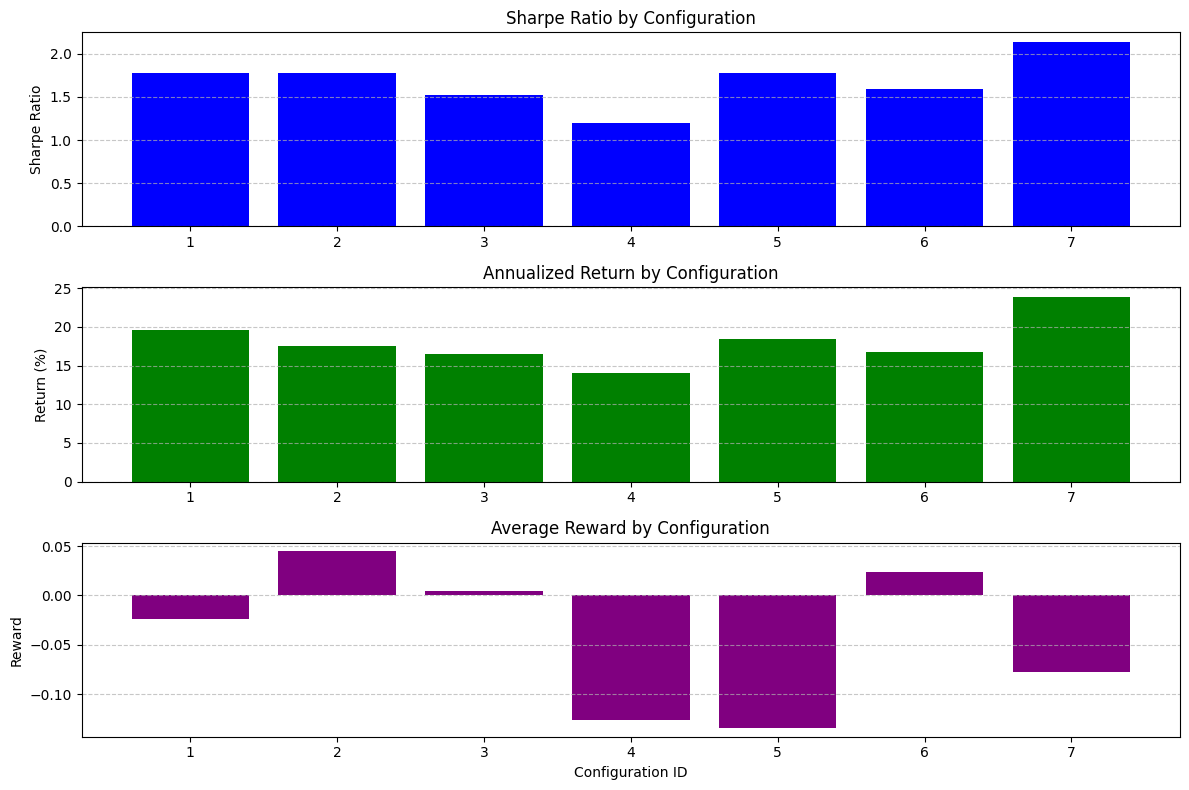

In [ ]:
tuning_results = hyperparameter_tuning(
    data_path="/Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv",  # Path to your data
    output_dir="tuning_models",  # Directory to save models and results
    batch_size=1650,  # Large enough to include all stocks
    lookback=30  # Same lookback window as in training
)

# Print a summary of the best models
print("\nHyperparameter Tuning Summary:")
print(f"Best by reward: Config {tuning_results['best_by_reward']['config_id']}")
print(f"Best by Sharpe ratio: Config {tuning_results['best_by_sharpe']['config_id']}")
print(f"Best by return: Config {tuning_results['best_by_return']['config_id']}")
print(f"Recommended: Config {tuning_results['recommended']['config_id']}")

# Save final tuning results to a readable format
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
summary_file = os.path.join("tuning_models", f"tuning_summary_{timestamp}.json")

with open(summary_file, "w") as f:
    json.dump({
        "best_models": {
            "best_by_reward": tuning_results["best_by_reward"],
            "best_by_sharpe": tuning_results["best_by_sharpe"],
            "best_by_return": tuning_results["best_by_return"],
            "recommended": tuning_results["recommended"]
        },
        "timestamp": timestamp
    }, f, indent=2)

print(f"\nTuning summary saved to {summary_file}")

# Create a comparison chart of the different configurations
try:
    import matplotlib.pyplot as plt

    # Extract data for plotting
    configs = [result["config_id"] for result in tuning_results["all_results"]]
    sharpe_ratios = [result["backtest"]["sharpe_ratio"] for result in tuning_results["all_results"]]
    returns = [result["backtest"]["annualized_return"] for result in tuning_results["all_results"]]
    rewards = [result["evaluation"]["avg_reward"] for result in tuning_results["all_results"]]

    # Create figure
    plt.figure(figsize=(12, 8))

    # Plot metrics
    plt.subplot(3, 1, 1)
    plt.bar(configs, sharpe_ratios, color='blue')
    plt.title('Sharpe Ratio by Configuration')
    plt.ylabel('Sharpe Ratio')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.subplot(3, 1, 2)
    plt.bar(configs, returns, color='green')
    plt.title('Annualized Return by Configuration')
    plt.ylabel('Return (%)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.subplot(3, 1, 3)
    plt.bar(configs, rewards, color='purple')
    plt.title('Average Reward by Configuration')
    plt.xlabel('Configuration ID')
    plt.ylabel('Reward')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join("tuning_models", f"tuning_comparison_{timestamp}.png"))
    plt.show()

except:
    print("Could not generate comparison charts")

## **BACKTESTING WITH BEAR MARKET AND HIGH VOLATILITY MARKET**

Starting stress tests at 2025-03-27 16:55:08.438489
Running portfolio stress tests...
Model expects exactly 1603 stocks
Dataset contains 1631 unique stocks
Using top 1603 stocks by volume

1. Bear Market Test
Identified 2009 as the worst year with -0.58% avg return
Bear market dataset has 1603 stocks and 251 days
Running 1-year backtest simulation...
Loading data from temp_bear_market.csv...
Original dataset has 1603 unique stocks
Processing 1603 stocks with 251 trading days
Date range: 2009-01-02 00:00:00 to 2009-12-31 00:00:00
Adding technical indicators...
Adding technical indicators in batches...
Processing batch 1/1 (1603 stocks)


Batch 1 indicators: 100%|██████████| 1603/1603 [00:28<00:00, 57.03it/s]


Technical indicators added successfully
Scaling features...
Scaling features in batches...


Scaling batch 1/1: 100%|██████████| 1603/1603 [00:46<00:00, 34.83it/s]


Preparing training data...
Preparing training data in batches...
Processing dates batch 1/9


...

Processing dates batch 3/3


Dates batch 3: 100%|██████████| 1/1 [00:00<00:00,  7.82it/s]


Training data preparation complete
Data preparation complete!
Backtest includes 1603 stocks with sufficient data


Backtest progress: 31days [00:01, 24.90days/s]


Portfolio Value: 10074.29, Transaction Costs: 0.32, Reward: -0.000064

Backtest Summary:
Initial investment: $10000.00
Final value: $10074.29
Total return: 0.74%
Annualized return: 6.37%
Volatility: 5.67%
Sharpe ratio: 0.77
Maximum drawdown: 1.97%
Win rate: 70.97%
Average cash allocation: 9.93%
Average number of holdings: 748.1 stocks
Average daily turnover: 12.09%

========== Stress Test Summary ==========
                    | Bear Market | High Volatility
------------------------------------------------------------
Total Return (%)    |        19.66 |
Annualized Return   |        22.87 |
Maximum Drawdown    |         2.94 |
Sharpe Ratio        |         4.20 |
High Volatility Test:
  Total Return: 0.74%
  Annualized Return: 6.37%
  Maximum Drawdown: 1.97%
  Sharpe Ratio: 0.77
Stress test results saved to results/stress_test_results_20250327_165508.json


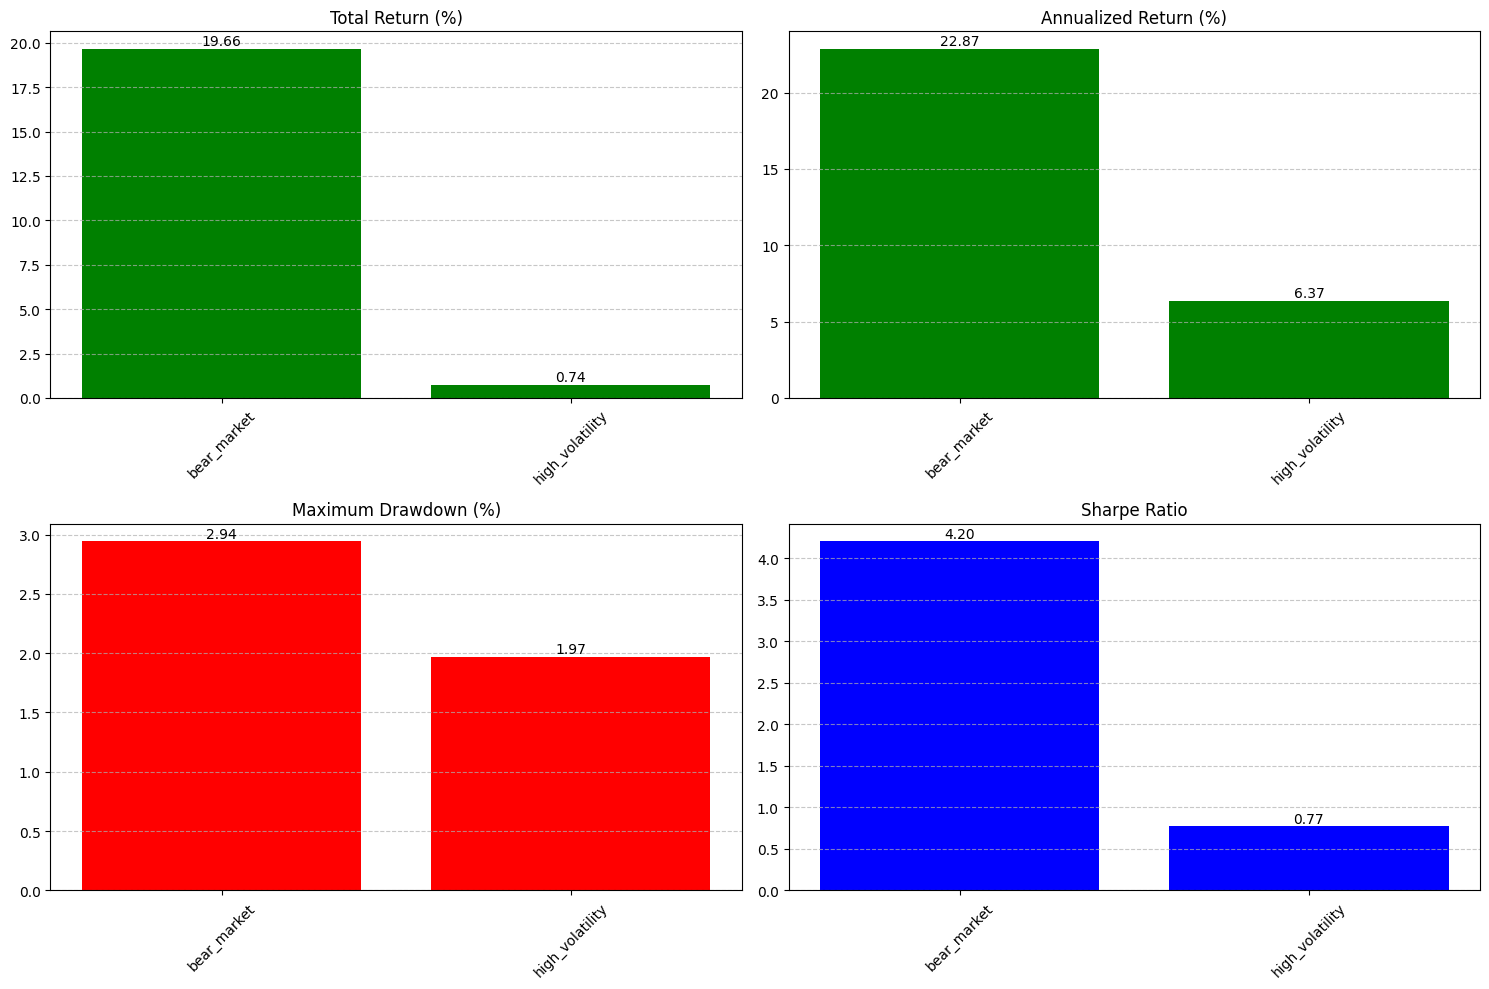

Stress tests completed at 2025-03-27 16:58:14.974413


In [ ]:
import matplotlib.pyplot as plt


# Path to your trained model
model_path = "/Users/rajkaranyp/Documents/PPO/Modelpath.zip"  # Update this if you used a different path
model = PPO.load(model_path)

# Path to your data
data_path = "/Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv"  # Update this to your data path

# Create results directory
os.makedirs("results", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Run stress tests
print(f"Starting stress tests at {datetime.now()}")
stress_test_results = stress_test_portfolio(
    model=model,
    data_path=data_path,
    lookback=30,  # Use the same lookback window as in training
    initial_cash=10000,  # Initial investment amount
    batch_size=1650  # Large enough to include all stocks
)

# Save stress test results
stress_test_file = os.path.join("results", f"stress_test_results_{timestamp}.json")
with open(stress_test_file, "w") as f:
    # Convert any numpy values to standard Python types for JSON serialization
    serializable_results = {}
    for scenario, metrics in stress_test_results.items():
        serializable_results[scenario] = {k: float(v) for k, v in metrics.items()}

    json.dump(serializable_results, f, indent=2)

print(f"Stress test results saved to {stress_test_file}")

# Create visualization of stress test results
plt.figure(figsize=(15, 10))

# Extract data for plotting
scenarios = list(stress_test_results.keys())
metrics = ['total_return', 'annualized_return', 'max_drawdown', 'sharpe_ratio']
metric_labels = ['Total Return (%)', 'Annualized Return (%)', 'Maximum Drawdown (%)', 'Sharpe Ratio']

# Create a subplot for each metric
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    values = [stress_test_results[scenario].get(metric, 0) for scenario in scenarios]

    # Use different colors for positive/negative values for returns
    if 'return' in metric:
        colors = ['green' if v > 0 else 'red' for v in values]
    elif 'drawdown' in metric:
        colors = ['red' for v in values]  # Always red for drawdowns
    else:
        colors = ['blue' for v in values]

    plt.bar(scenarios, values, color=colors)
    plt.title(metric_labels[i])
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top of each bar
    for j, v in enumerate(values):
        plt.text(j, v + (0.01 * max(abs(min(values)), abs(max(values)))),
                 f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig(os.path.join("results", f"stress_test_comparison_{timestamp}.png"))
plt.show()

print(f"Stress tests completed at {datetime.now()}")

## **CALLING RECOMMENDER FUNCTION**

In [ ]:
# Initialize the recommender
recommender = PortfolioRecommender(
    model_path="/Users/rajkaranyp/Documents/PPO/Modelpath.zip",
    data_path="/Users/rajkaranyp/Documents/Capstone_Project/Datasets/historical_data.csv",
    lookback=30
)

# Generate portfolio with gradually decreasing allocations
recommendation = recommender.recommend_portfolio(
    amount_cad=10000,            # $10,000 to invest
    target_stock_allocation=0.9, # 90% in stocks
    cash_allocation=0.1,         # 10% in cash
    min_stocks=25,               # At least 25 stocks
    max_stocks=40                # At most 40 stocks
)

Model expects exactly 1603 stocks
Most recent date in dataset: 2024-12-30 00:00:00
Found 1600 stocks with sufficient history
Using exactly 1603 stocks for recommendation
Preparing recommendation features...
Features shape: (1603, 30, 9) (should be 1603, 30, 9)
Features prepared successfully
Generating portfolio recommendation for $10000.00 CAD...

GENERATING PORTFOLIO RECOMMENDATION
Allocation Summary:
Cash: 10.00%
Stocks: 90.00%
Number of stocks allocated: 40
Max allocation: 9.14%
Min allocation: 0.15%
Avg allocation: 2.25%
Recommended portfolio allocation (as of 2024-12-30 00:00:00):
Cash: $1000.00 (10.00%)
Stock allocations:
IICE.TO: $913.50 (9.14%) - 40.4026 shares @ $22.61
YGR.TO: $822.15 (8.22%) - 783.0021 shares @ $1.05
FTU.TO: $739.94 (7.40%) - 1541.5353 shares @ $0.48
HBB.TO: $665.94 (6.66%) - 13.6046 shares @ $48.95
KXS.TO: $599.35 (5.99%) - 3.4503 shares @ $173.71
PDIV.TO: $539.41 (5.39%) - 58.5048 shares @ $9.22
BAM.TO: $485.47 (4.85%) - 6.1978 shares @ $78.33
RCH.TO: $436.